E: Failed to fetch http://archive.ubuntu.com/ubuntu/pool/main/libi/libidn/libidn12_1.38-4ubuntu1_amd64.deb  404  Not Found [IP: 185.125.190.82 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/p/poppler/poppler-utils_22.02.0-2ubuntu0.12_amd64.deb  404  Not Found [IP: 185.125.190.82 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?


In [ ]:
import os, subprocess, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from scikeras.wrappers import KerasClassifier
from google.colab import files as gfiles


FONT_PATH = '/content/times.ttf'

fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600

OUT_DIR = "/content/plots"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
def save_light_eps(fig, name, dpi=600):

    path = os.path.join(OUT_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=dpi, bbox_inches='tight')
    size_kb = os.path.getsize(path) / 1024
    print(f"Saved {path}  ({size_kb:.1f} KB)")
    return path


def save_heavy_pdf_to_eps(fig, name, dpi=600):

    pdf_path = os.path.join(OUT_DIR, f"{name}.pdf")
    eps_path = os.path.join(OUT_DIR, f"{name}.eps")
    fig.savefig(pdf_path, format='pdf', dpi=dpi, bbox_inches='tight')

    converted = False
    try:
        subprocess.run(["pdftops", "-eps", pdf_path, eps_path],
                        check=True, capture_output=True)
        converted = True
    except Exception as e:
        print("pdftops failed, falling back to ghostscript:", e)

    if not converted:
        subprocess.run(["gs", "-dNOPAUSE", "-dBATCH", "-dEPSCrop",
                         "-sDEVICE=eps2write", f"-r{dpi}",
                         f"-sOutputFile={eps_path}", pdf_path], check=True)

    size_kb = os.path.getsize(eps_path) / 1024
    print(f"Saved {eps_path}  ({size_kb:.1f} KB)")
    if size_kb > 100:
        print(f"WARNING: {name}.eps is {size_kb:.1f} KB -> exceeds 100 KB target.")
    os.remove(pdf_path)
    return eps_path

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape :", x_test.shape, y_test.shape)
print("Number of classes  :", len(np.unique(y_train)))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28) (60000,)
Testing data shape : (10000, 28, 28) (10000,)
Number of classes  : 10


In [ ]:
!apt-get update -qq
!apt-get install -y poppler-utils ghostscript
!which pdftops
!which gs

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 libgs9 libgs9-common
  libidn12 libijs-0.35 libjbig2dec0 libpoppler-dev libpoppler-private-dev
  libpoppler118 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-ukai
  fonts-arphic-uming fonts-nanum
The following NEW packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript libgs9
  libgs9-common libidn12 libijs-0.35 libjbig2dec0 poppler-data poppler-utils
The following packages will be upgrad

Saved /content/plots/01_sample_images.eps  (397.9 KB)


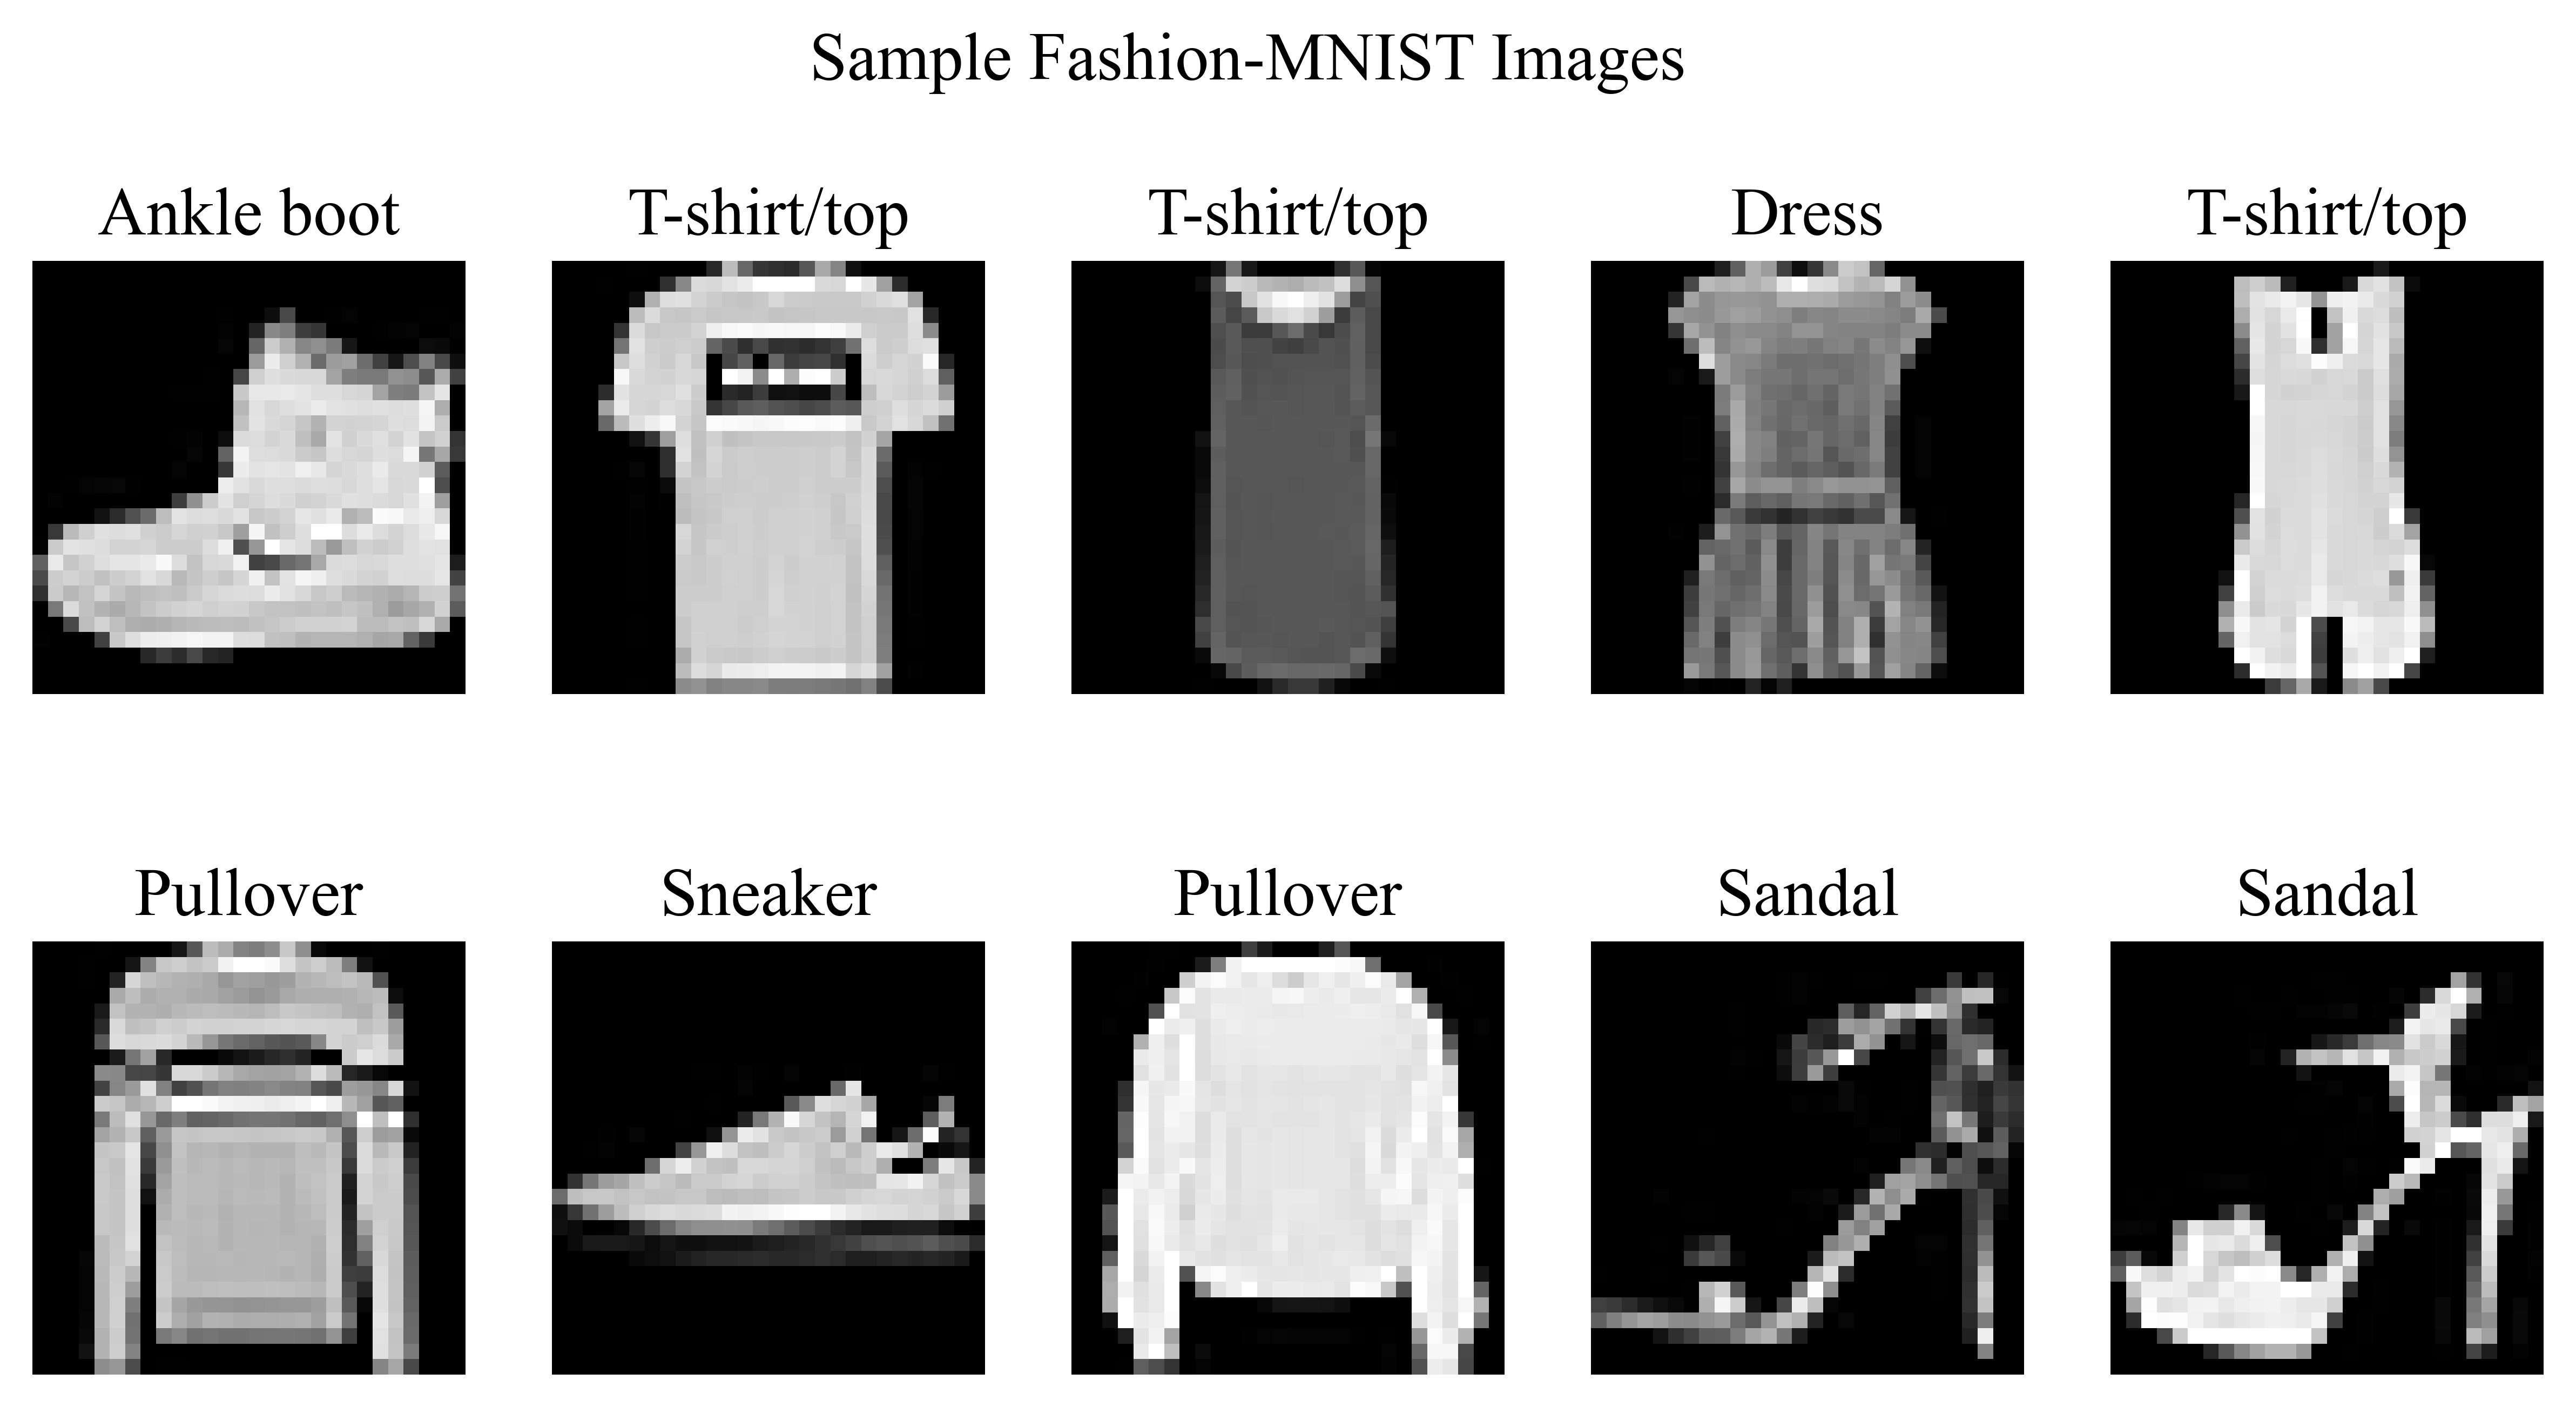

Saved /content/plots/01_sample_images.eps  (114.2 KB)


'/content/plots/01_sample_images.eps'

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray', interpolation='nearest')
    ax.set_title(class_names[y_train[i]], fontsize=15)
    ax.axis('off')
fig.suptitle("Sample Fashion-MNIST Images", fontsize=15)
save_heavy_pdf_to_eps(fig, "01_sample_images")
plt.show()
save_heavy_pdf_to_eps(fig, "01_sample_images", dpi=150)

Saved /content/plots/02_class_distribution.eps  (34.5 KB)


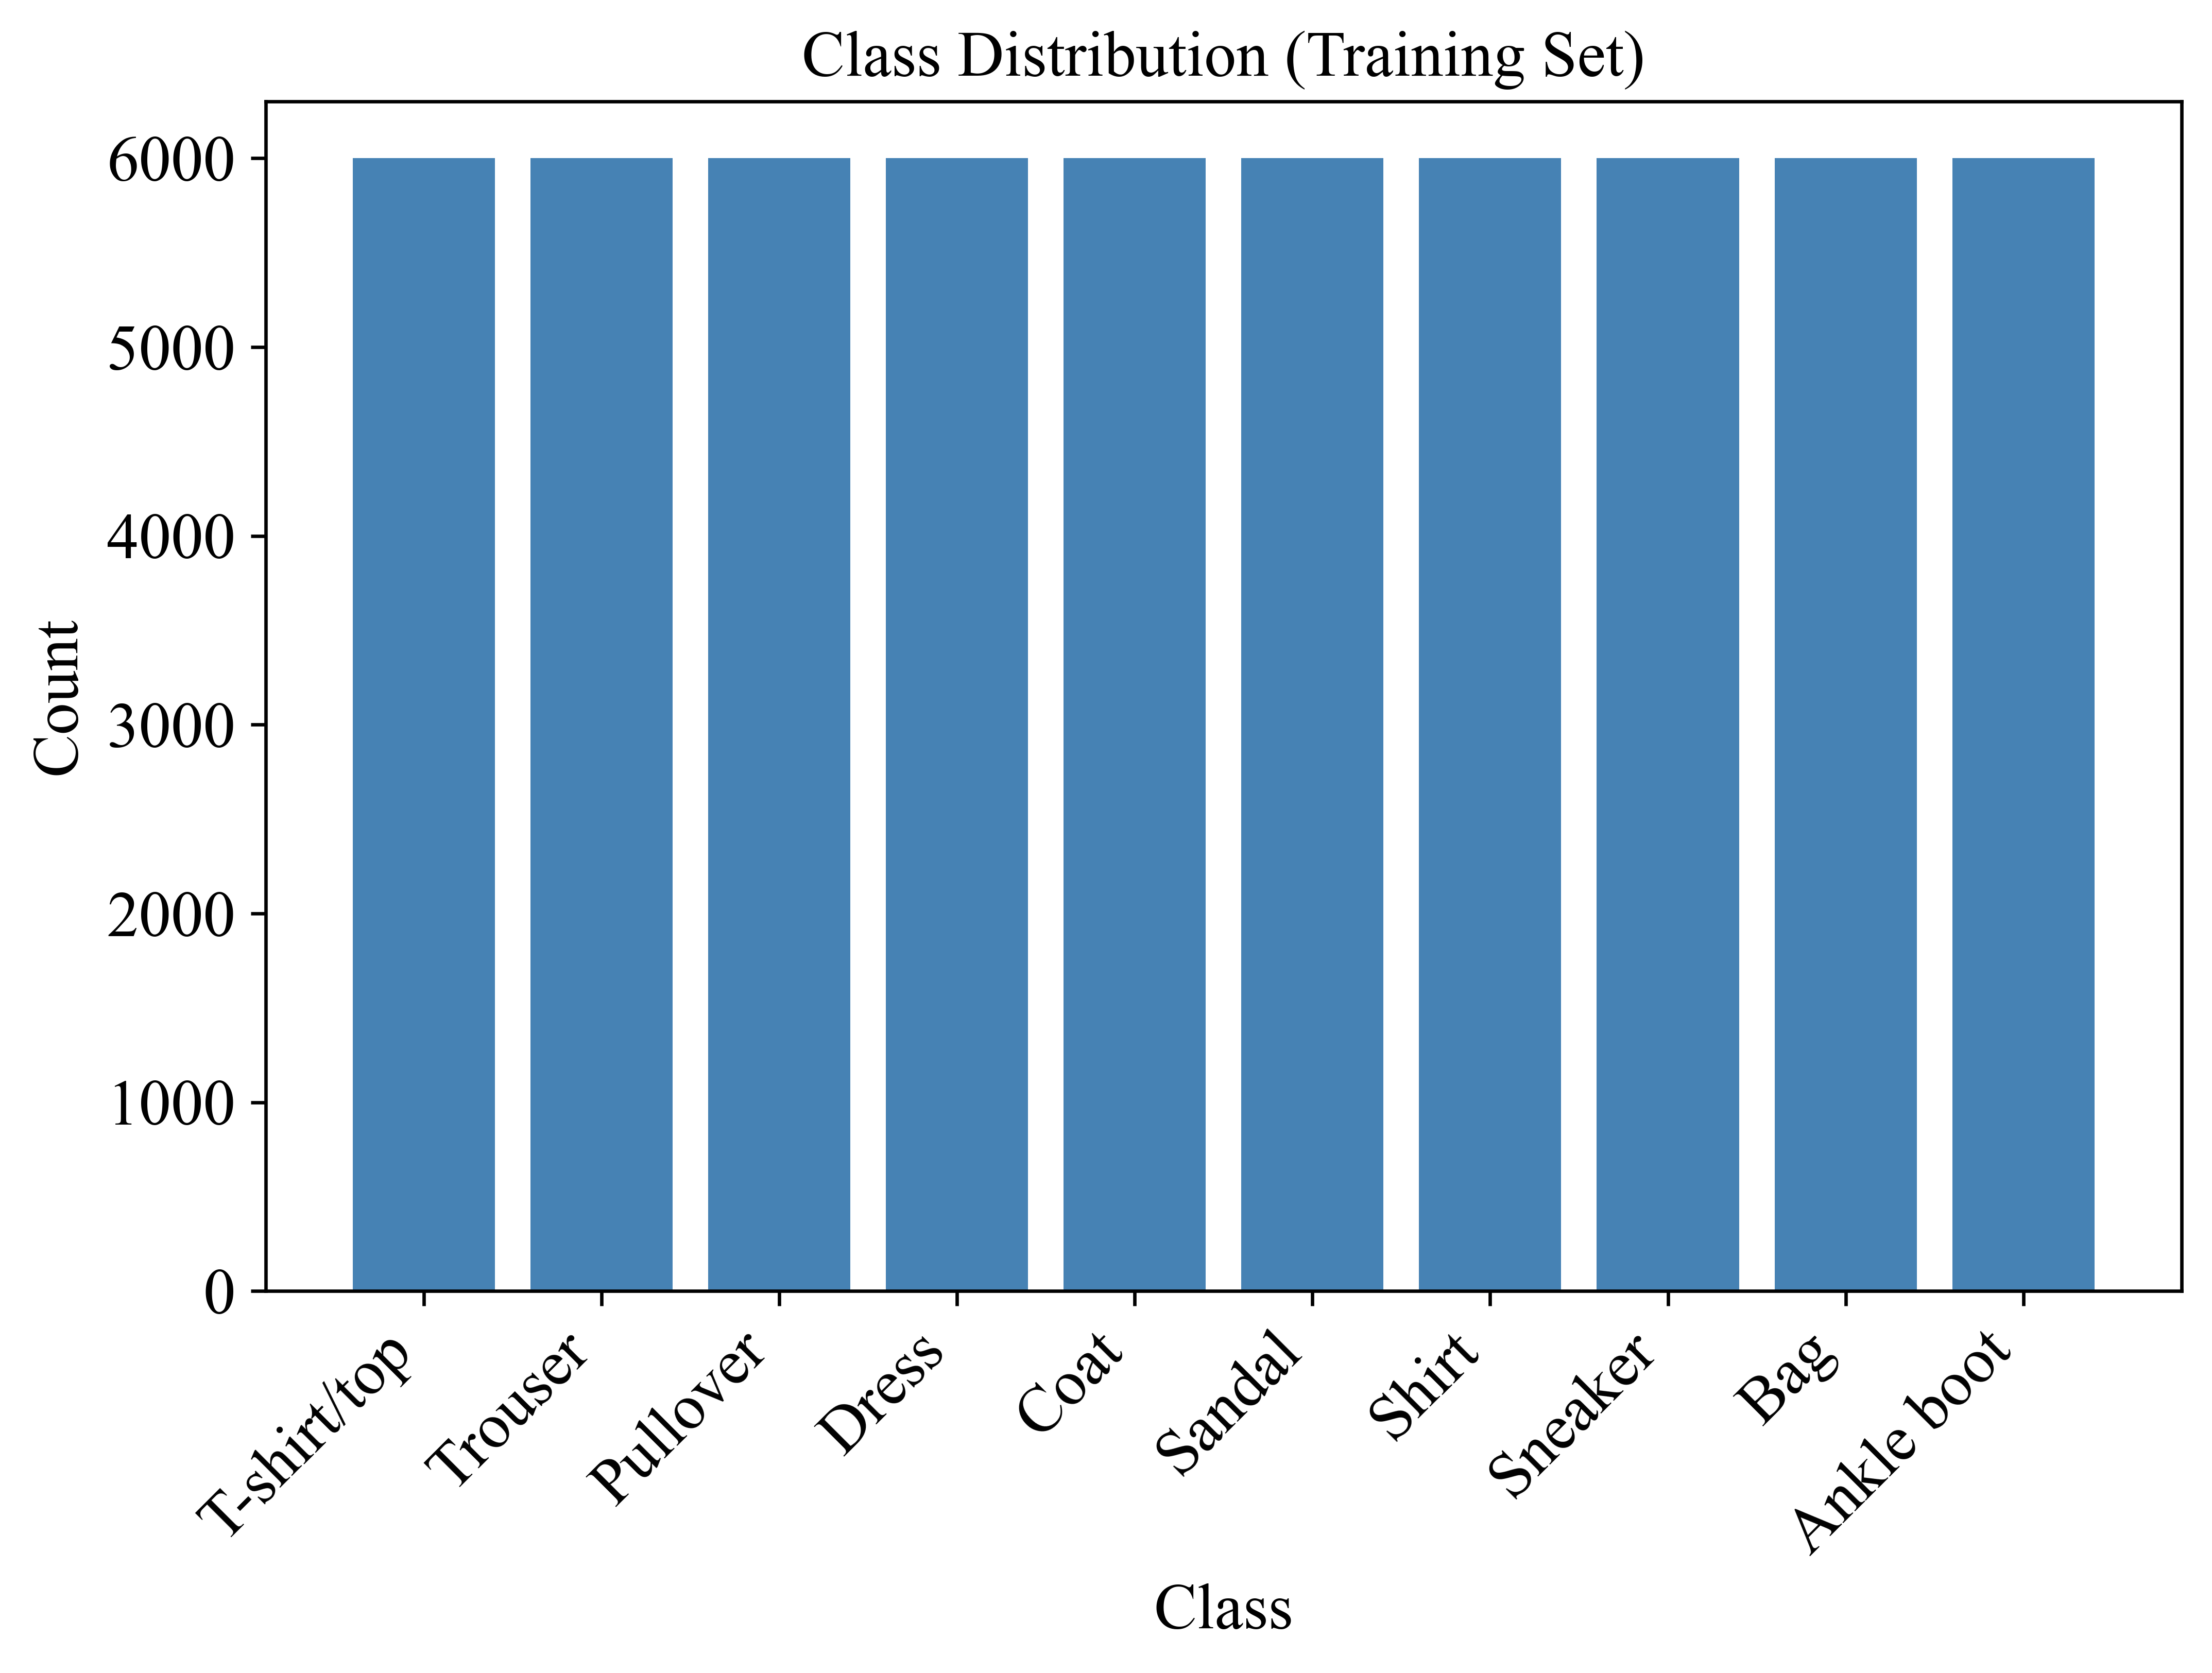

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([class_names[i] for i in unique], counts, color='steelblue')
ax.set_xlabel("Class", fontsize=15)
ax.set_ylabel("Count", fontsize=15)
ax.set_title("Class Distribution (Training Set)", fontsize=15)
plt.xticks(rotation=45, ha='right', fontsize=15)
save_light_eps(fig, "02_class_distribution")
plt.show()


In [ ]:
print("Before preprocessing - x_train shape:", x_train.shape, "dtype:", x_train.dtype)

x_train_flat = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("After preprocessing - x_train_flat shape:", x_train_flat.shape)
print("After preprocessing - x_test_flat shape :", x_test_flat.shape)
print("After preprocessing - y_train_oh shape  :", y_train_oh.shape)
print("After preprocessing - y_test_oh shape   :", y_test_oh.shape)

Before preprocessing - x_train shape: (60000, 28, 28) dtype: uint8
After preprocessing - x_train_flat shape: (60000, 784)
After preprocessing - x_test_flat shape : (10000, 784)
After preprocessing - y_train_oh shape  : (60000, 10)
After preprocessing - y_test_oh shape   : (10000, 10)


In [ ]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

history = baseline_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8177 - loss: 0.5116 - val_accuracy: 0.8578 - val_loss: 0.3906
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8615 - loss: 0.3740 - val_accuracy: 0.8703 - val_loss: 0.3624
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8750 - loss: 0.3383 - val_accuracy: 0.8673 - val_loss: 0.3659
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8821 - loss: 0.3180 - val_accuracy: 0.8731 - val_loss: 0.3485
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8890 - loss: 0.2986 - val_accuracy: 0.8763 - val_loss: 0.3445
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8952 - loss: 0.2825 - val_accuracy: 0.8725 - val_loss: 0.3408
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8984 - loss: 0.2718 - val_accuracy: 0.8848 - val_loss: 0.3164
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9032 - loss: 0.2589 -

Saved /content/plots/03_train_accuracy.eps  (26.8 KB)


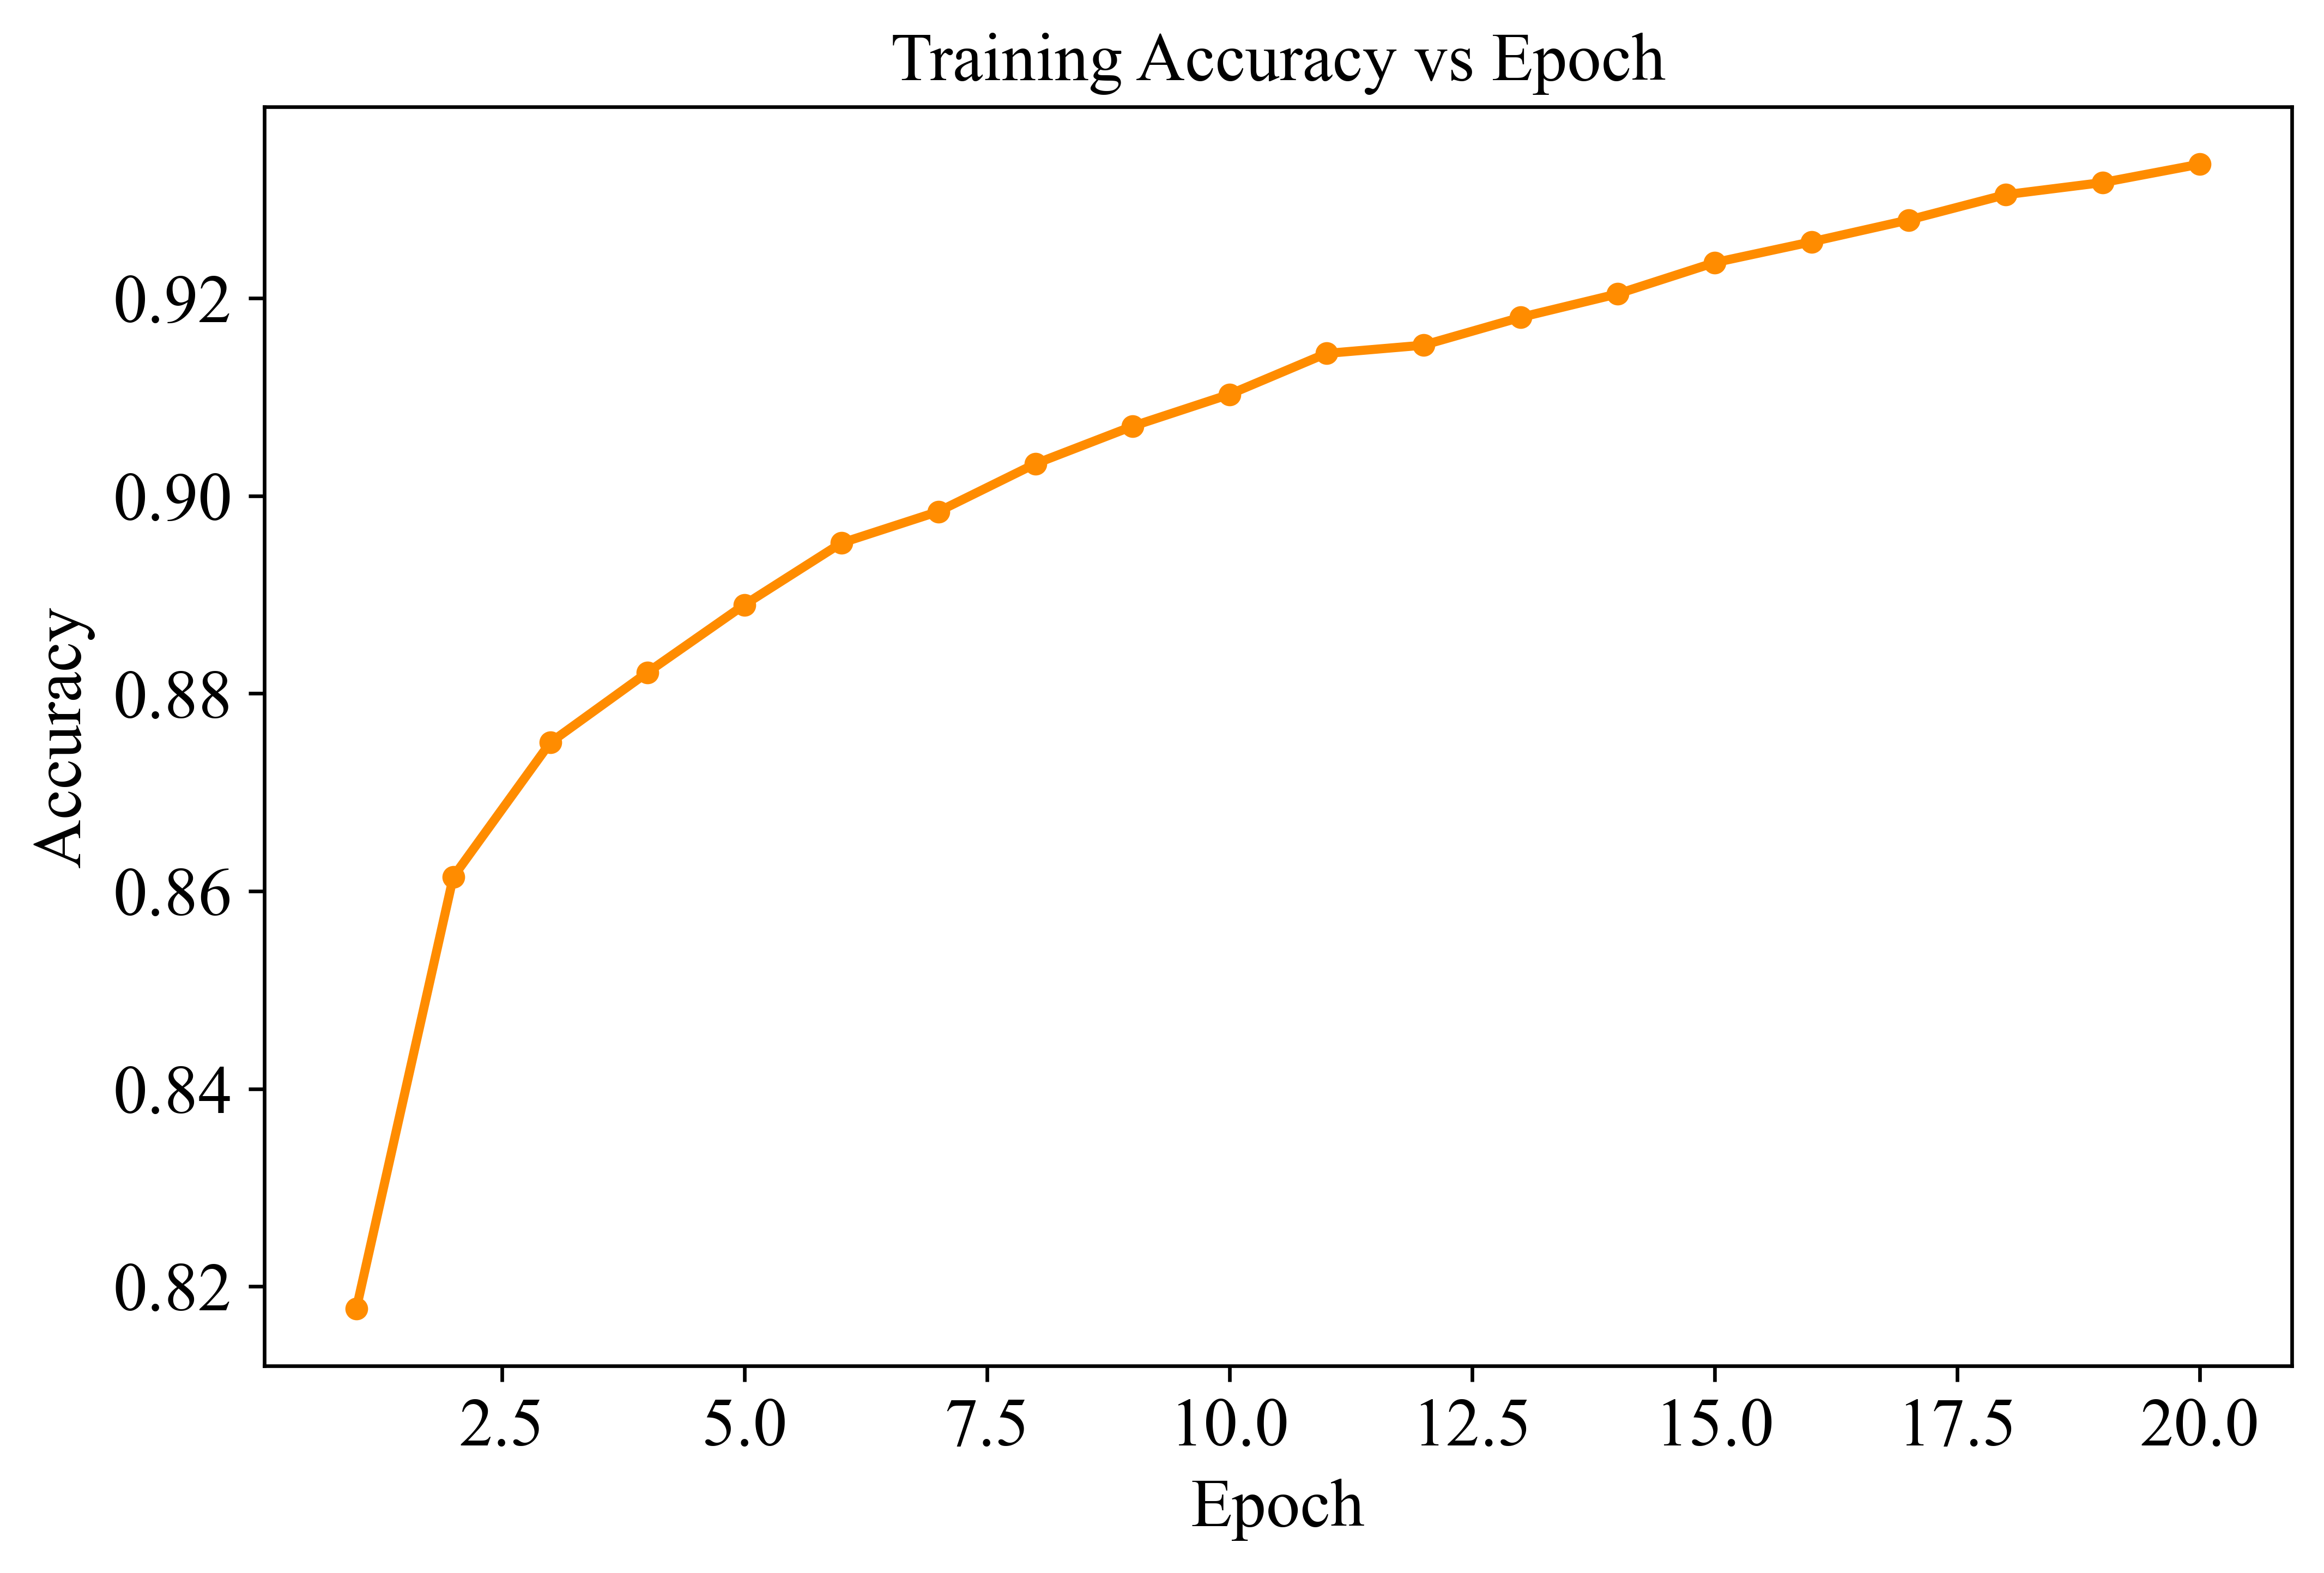

Saved /content/plots/04_val_accuracy.eps  (27.9 KB)


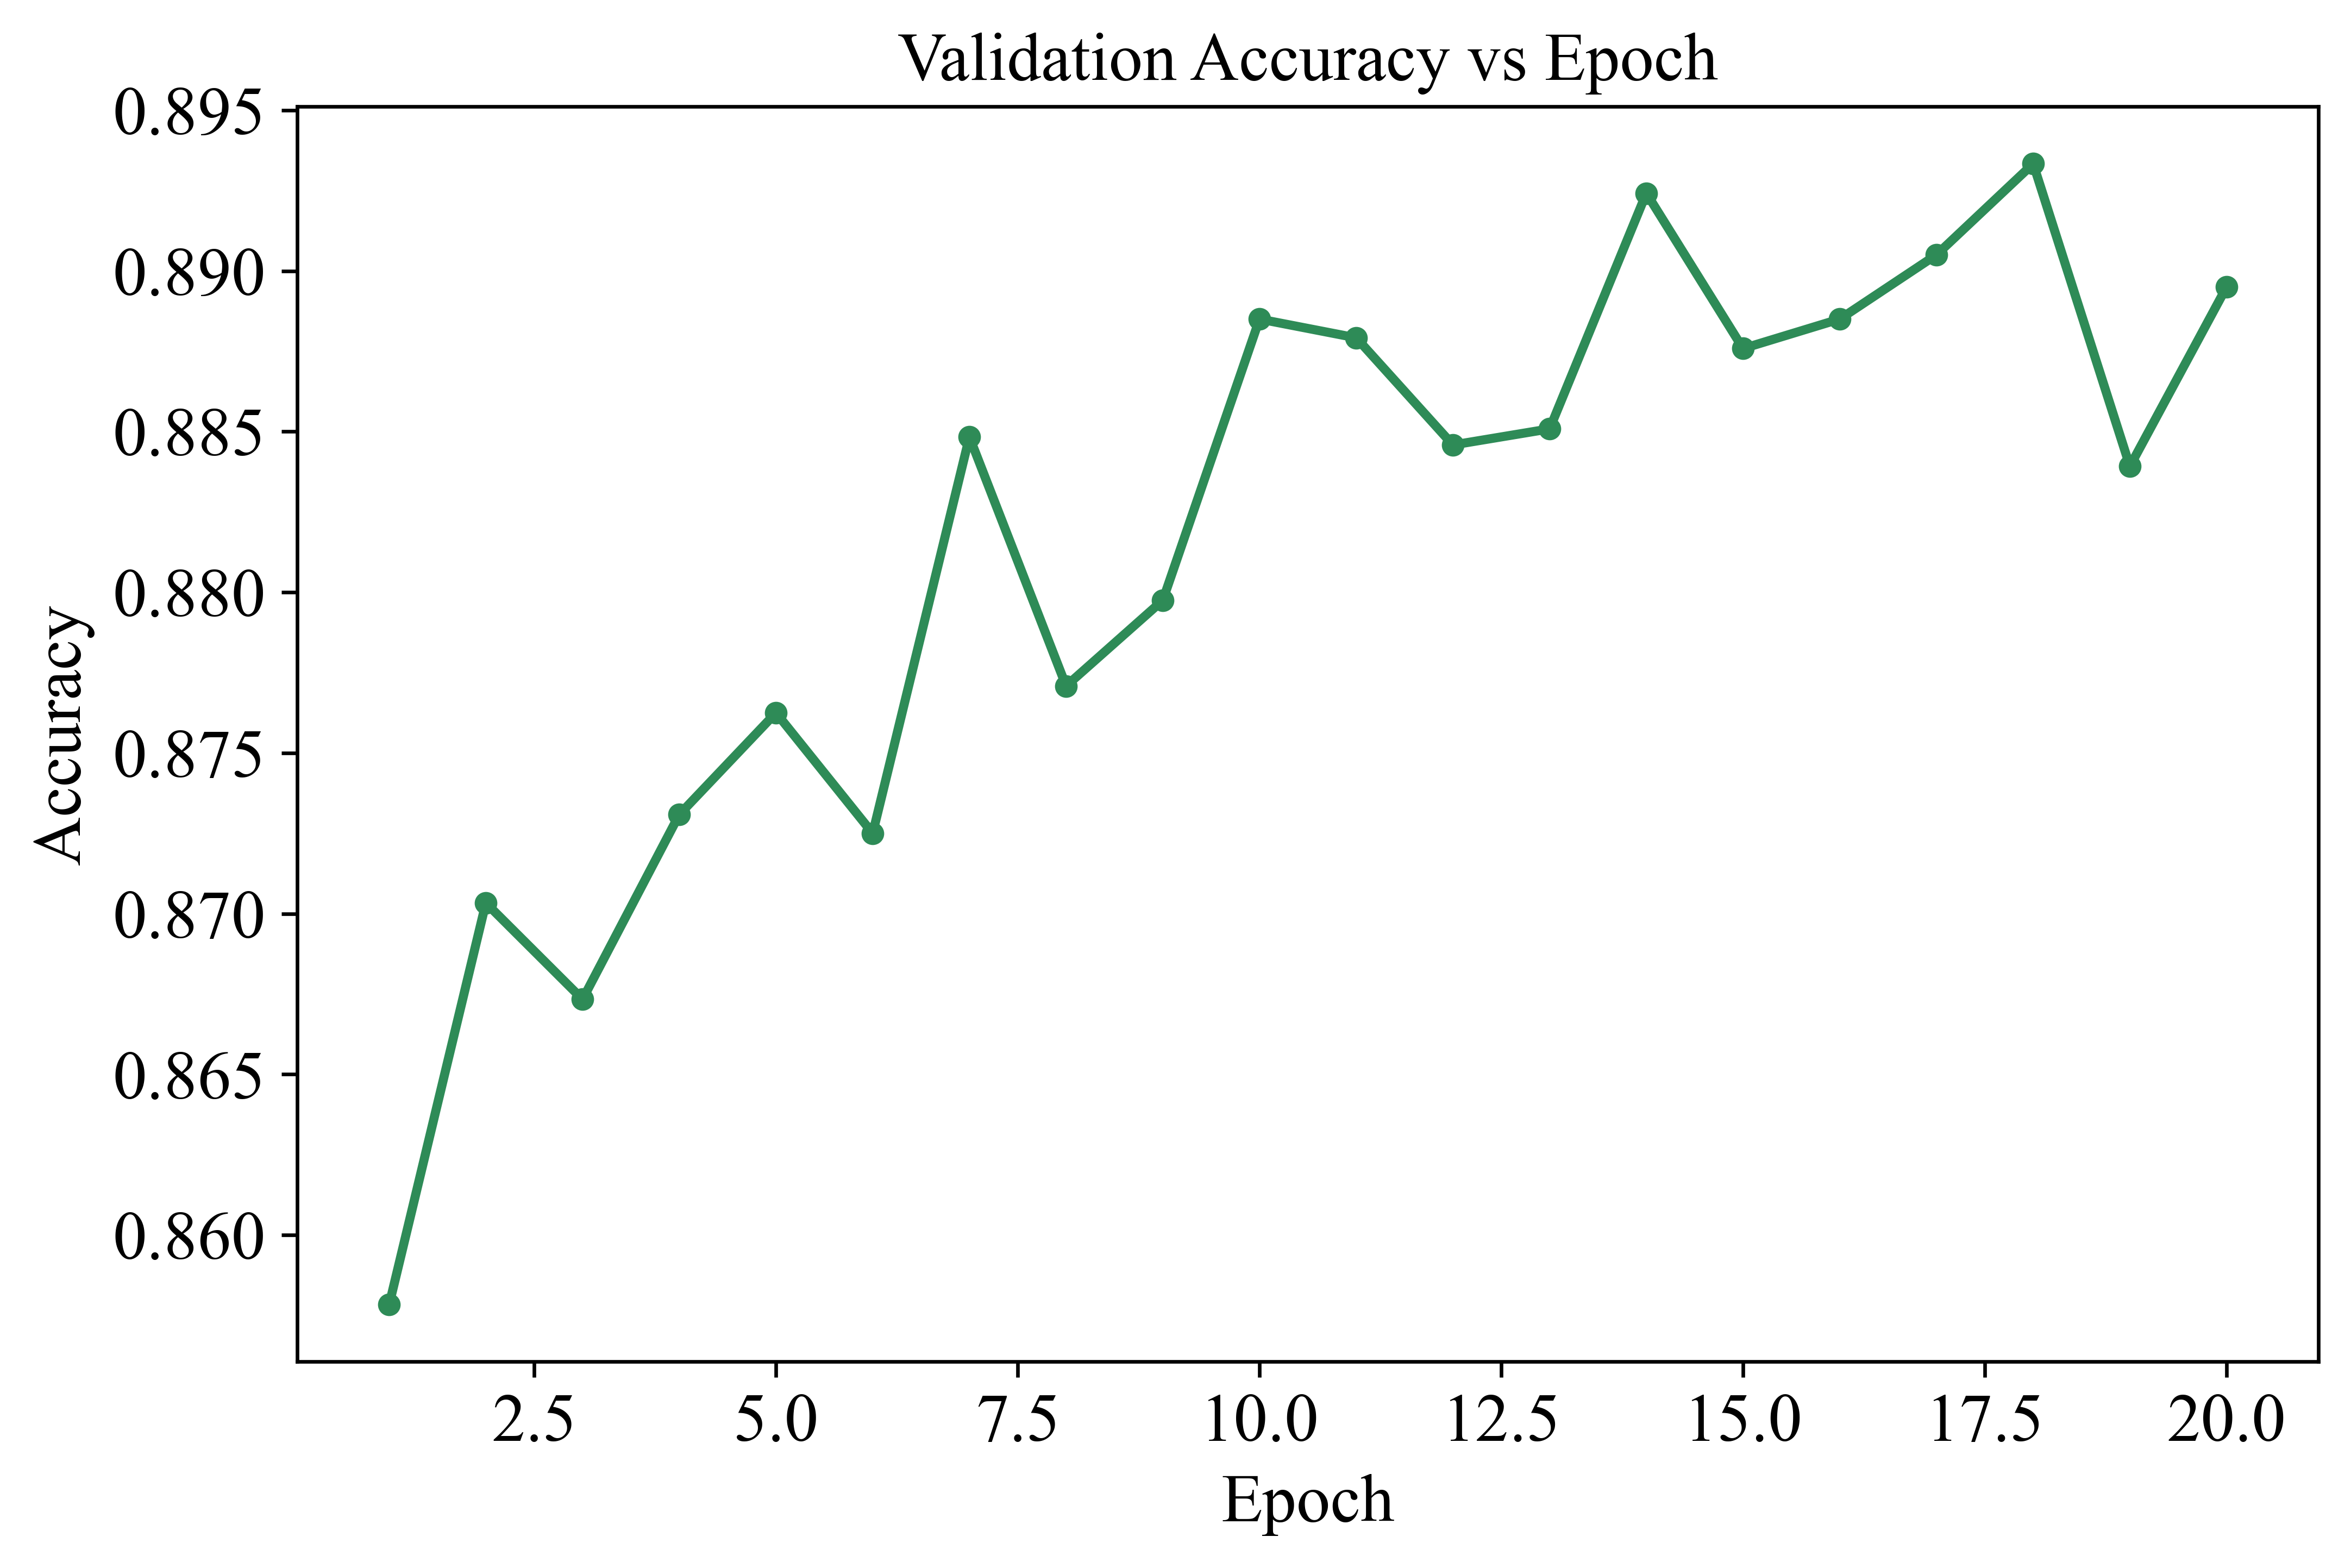

Saved /content/plots/05_train_loss.eps  (24.0 KB)


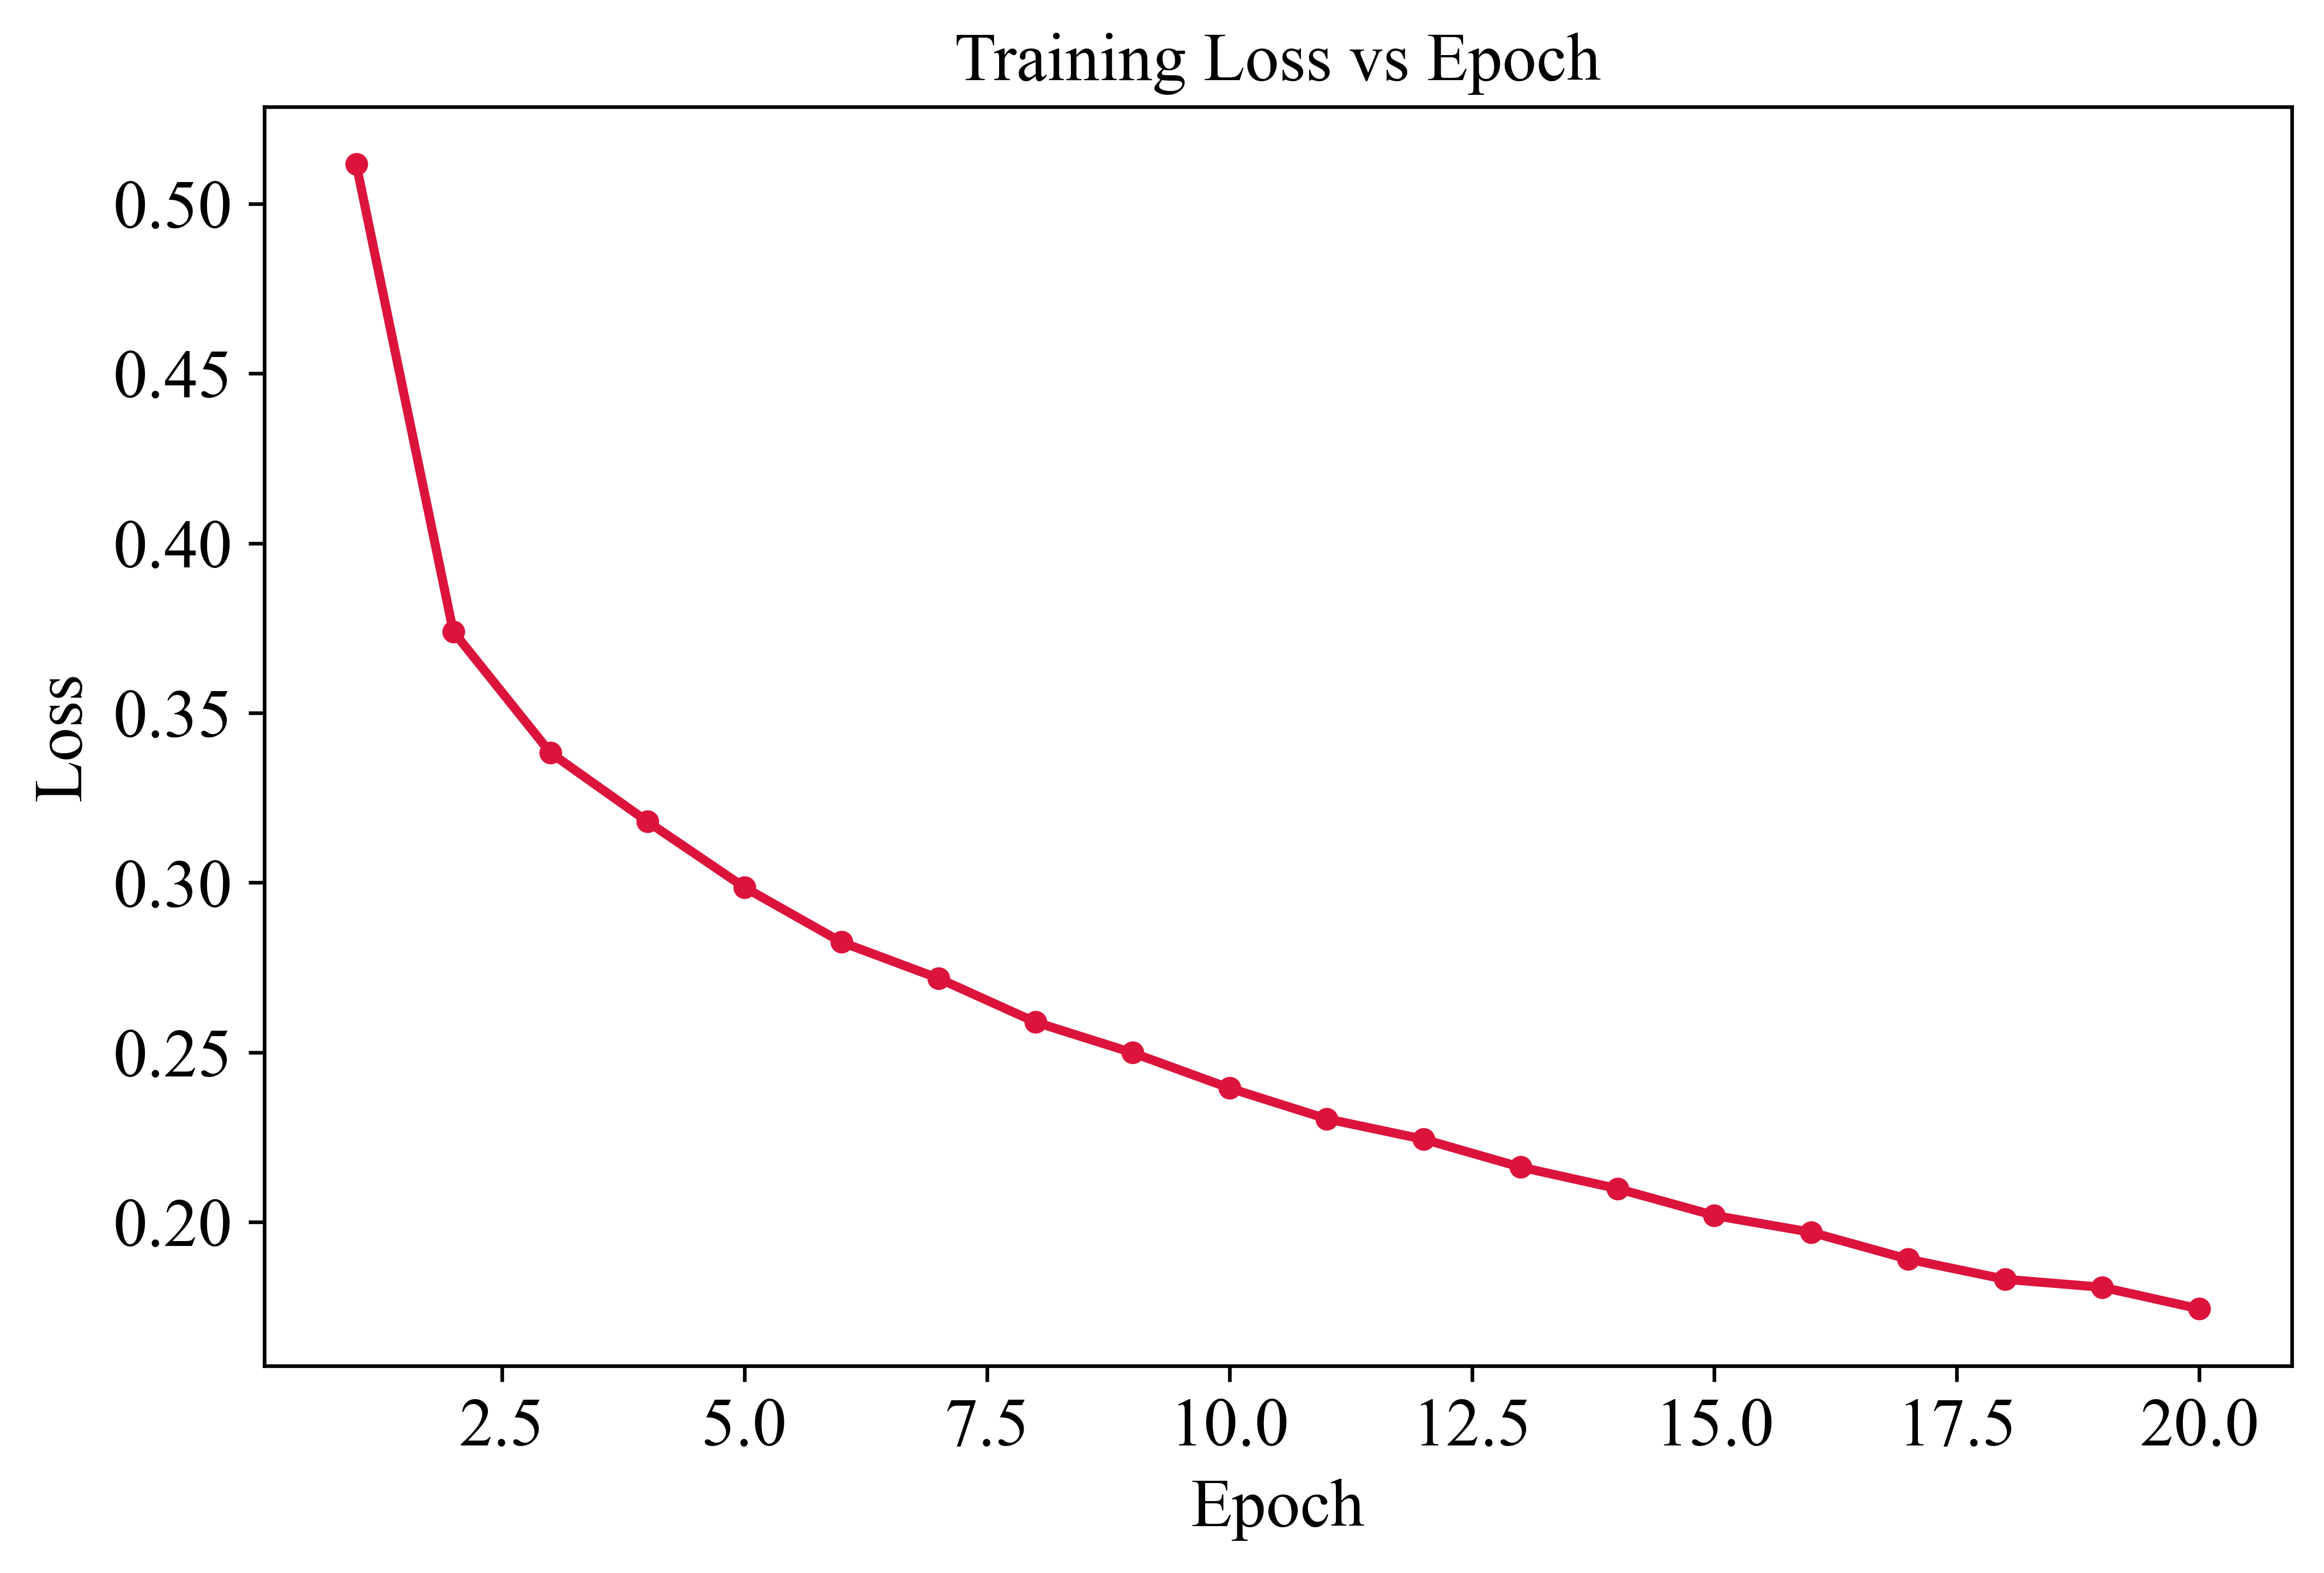

Saved /content/plots/06_val_loss.eps  (26.5 KB)


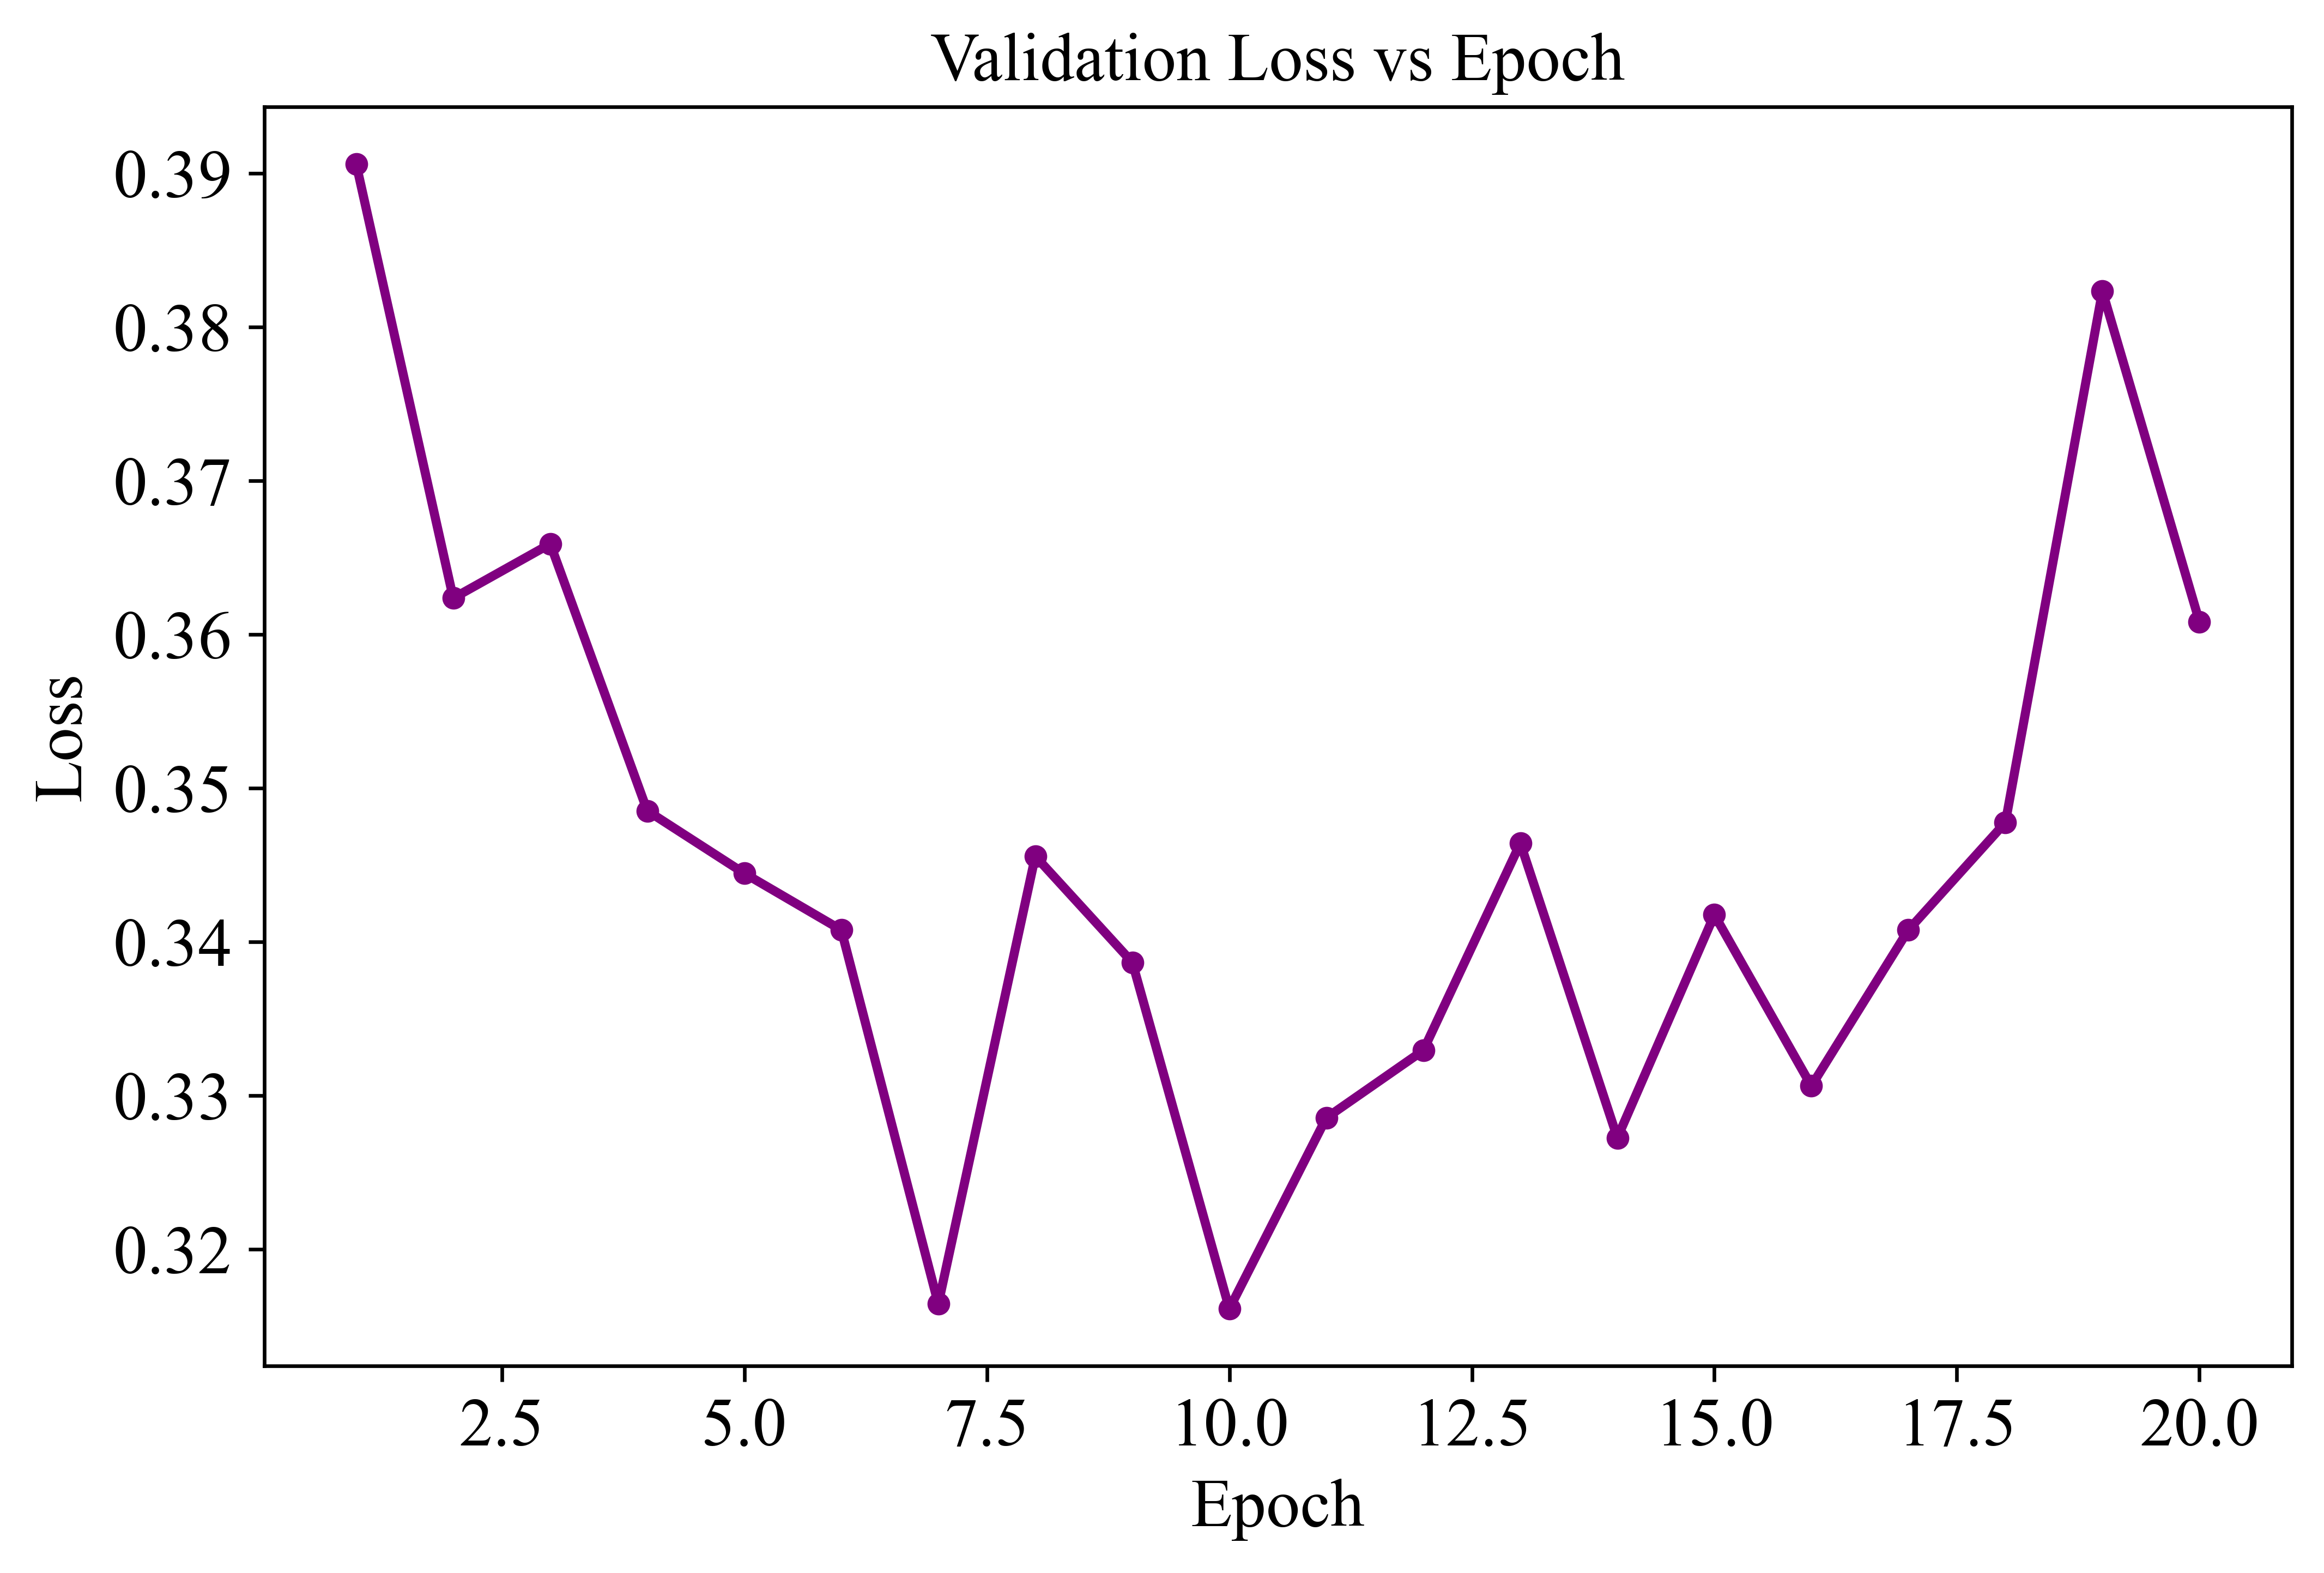

In [ ]:
def plot_metric(history_dict, key, ylabel, title, fname, color):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, len(history_dict[key]) + 1), history_dict[key],
            color=color, linewidth=2, marker='o', markersize=4)
    ax.set_xlabel("Epoch", fontsize=15)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_title(title, fontsize=15)
    save_light_eps(fig, fname)
    plt.show()

plot_metric(history.history, 'accuracy', 'Accuracy', 'Training Accuracy vs Epoch',
            '03_train_accuracy', 'darkorange')


plot_metric(history.history, 'val_accuracy', 'Accuracy', 'Validation Accuracy vs Epoch',
            '04_val_accuracy', 'seagreen')


plot_metric(history.history, 'loss', 'Loss', 'Training Loss vs Epoch',
            '05_train_loss', 'crimson')


plot_metric(history.history, 'val_loss', 'Loss', 'Validation Loss vs Epoch',
            '06_val_loss', 'purple')


In [ ]:
y_pred_prob = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)

baseline_acc = accuracy_score(y_test, y_pred)
baseline_prec = precision_score(y_test, y_pred, average='macro')
baseline_rec = recall_score(y_test, y_pred, average='macro')
baseline_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Baseline Accuracy : {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall   : {baseline_rec:.4f}")
print(f"Baseline F1-score : {baseline_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Baseline Accuracy : 0.8822
Baseline Precision: 0.8828
Baseline Recall   : 0.8822
Baseline F1-score : 0.8817

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.79      0.79      1000
       Dress       0.93      0.85      0.88      1000
        Coat       0.77      0.85      0.81      1000
      Sandal       0.99      0.94      0.96      1000
       Shirt       0.73      0.65      0.69      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Saved /content/plots/07_confusion_matrix_baseline.eps  (98.0 KB)


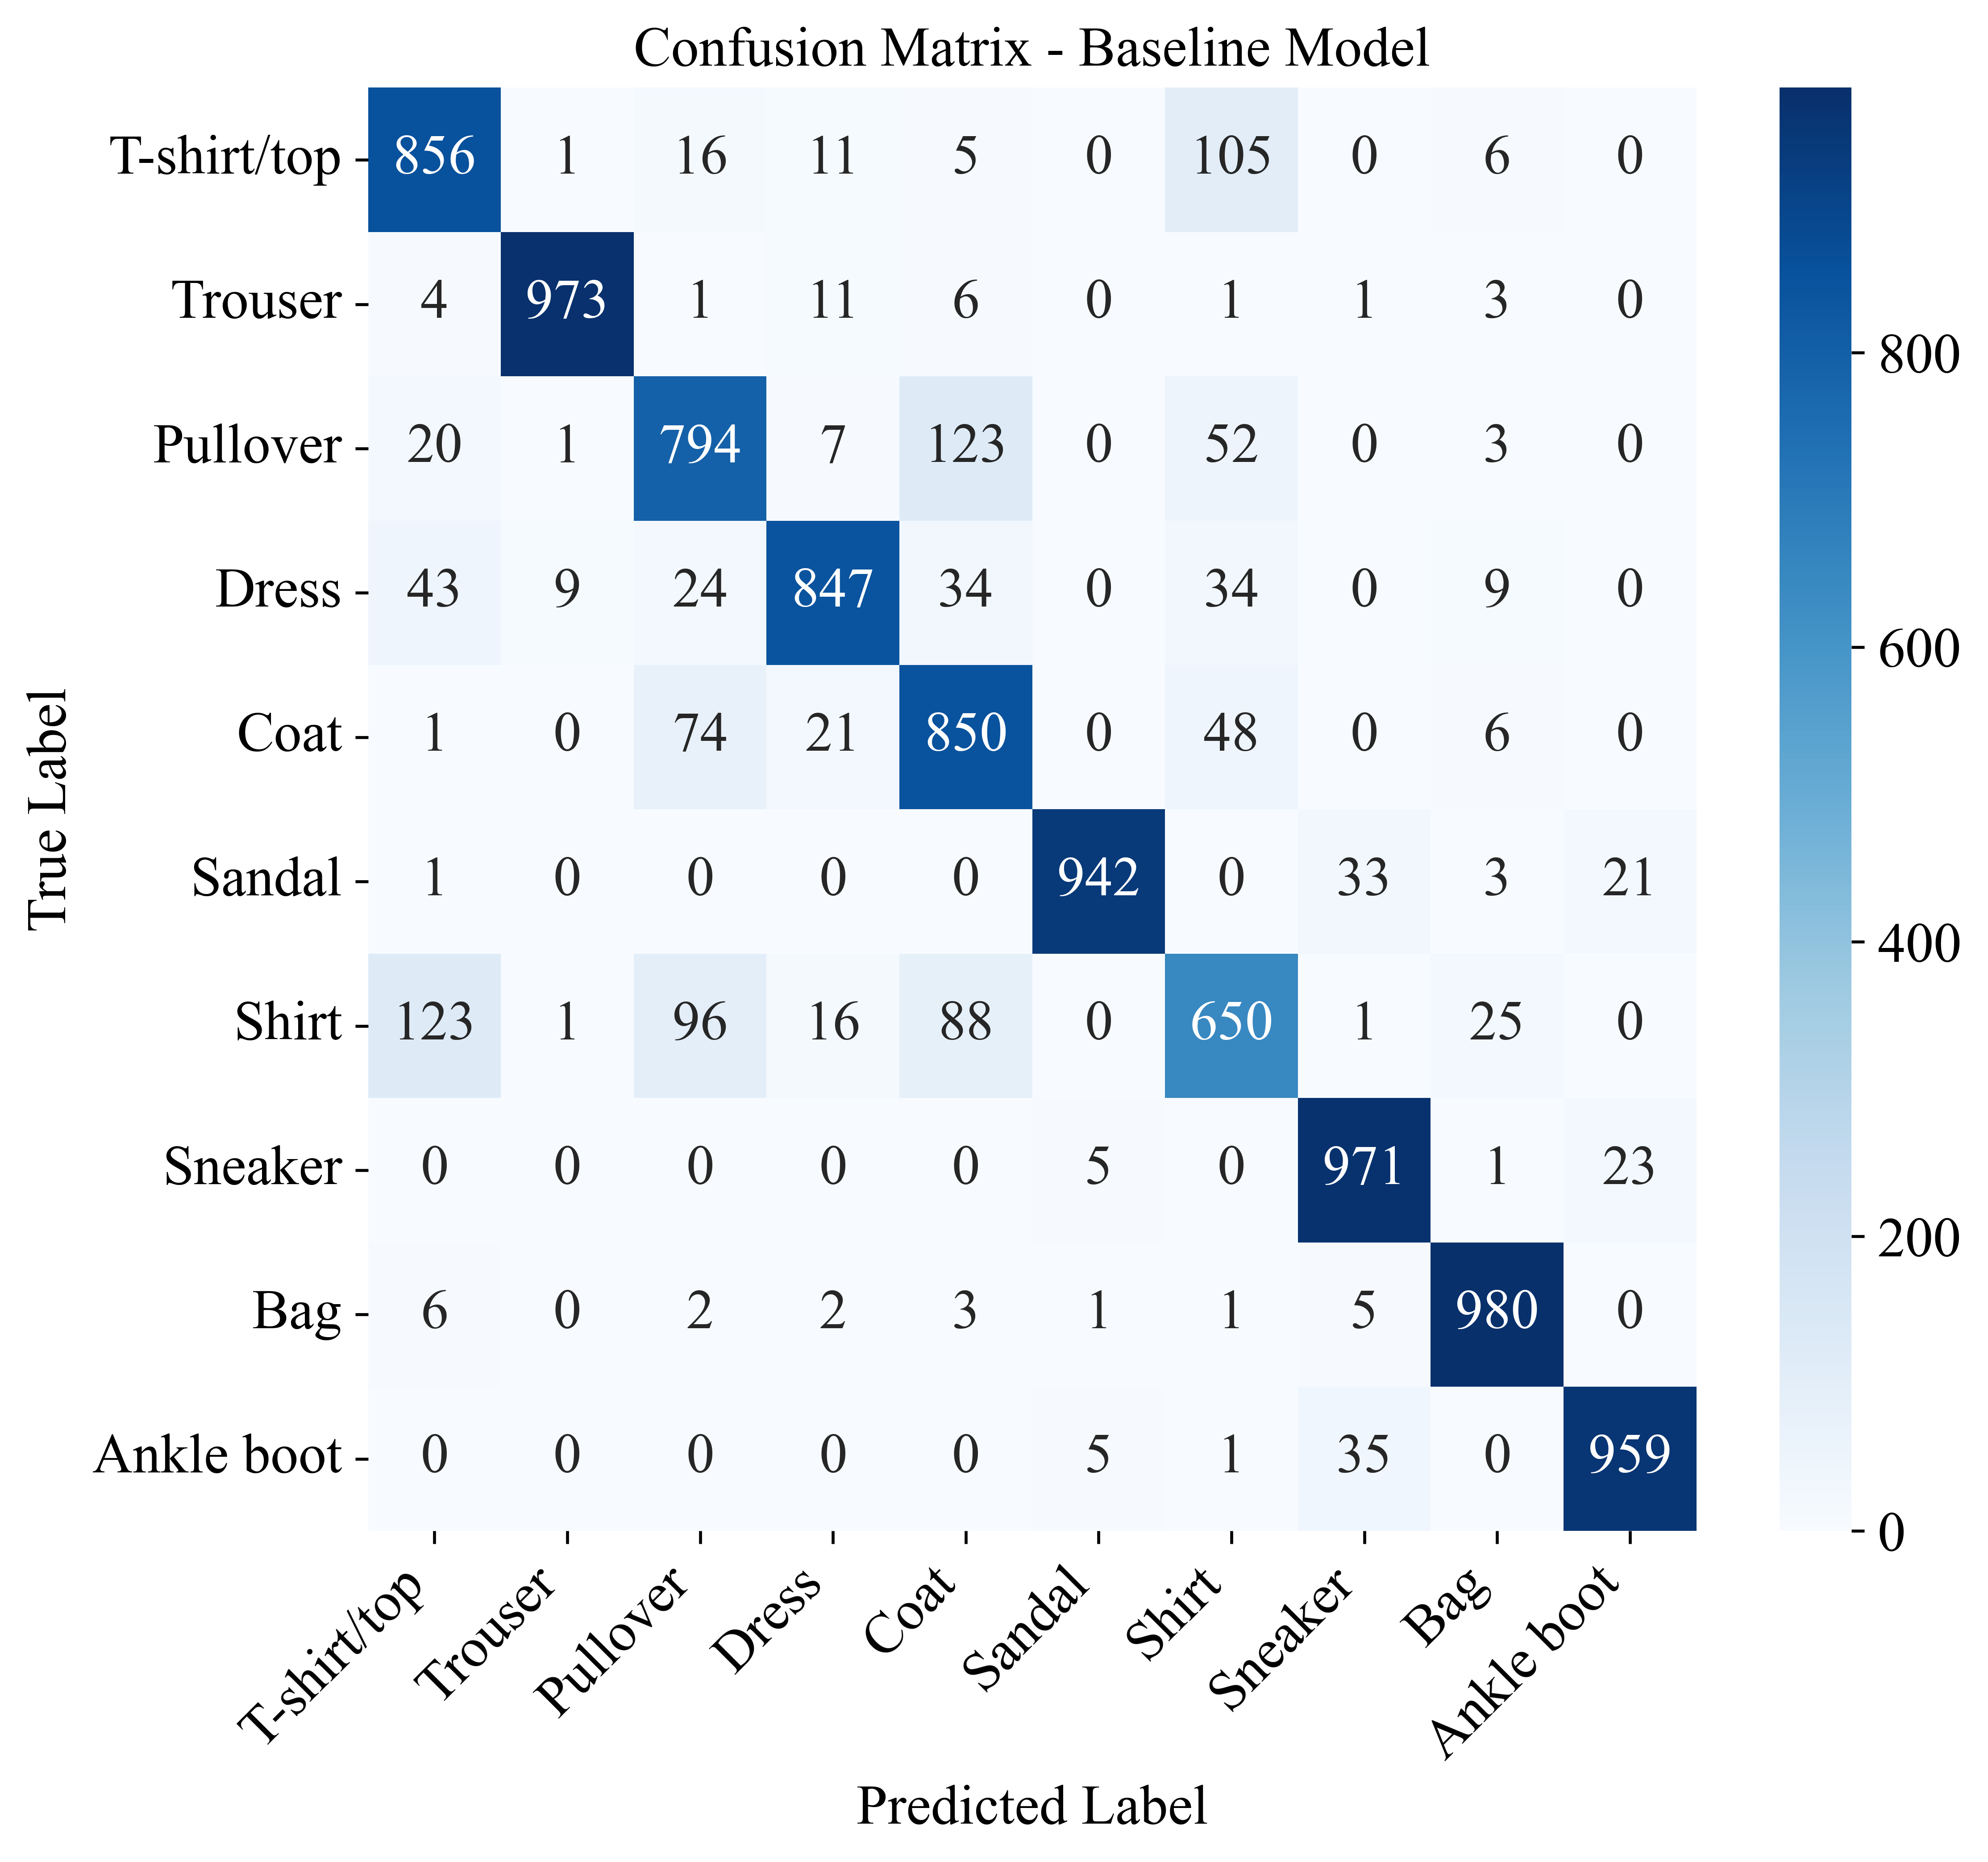

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={"size": 15}, cbar=True)
ax.set_xlabel("Predicted Label", fontsize=15)
ax.set_ylabel("True Label", fontsize=15)
ax.set_title("Confusion Matrix - Baseline Model", fontsize=15)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
save_heavy_pdf_to_eps(fig, "07_confusion_matrix_baseline")
plt.show()


In [ ]:
def build_model(hidden_layers=2, hidden_neurons=128, learning_rate=0.001,
                 optimizer_name='adam', activation='relu', dropout_rate=0.0,
                 meta=None):
    n_features_in = meta["n_features_in_"] if meta else 784
    n_classes = meta["n_classes_"] if meta else 10

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features_in,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation='softmax'))

    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
clf = KerasClassifier(
    model=build_model,
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer_name='adam',
    activation='relu',
    dropout_rate=0.0,
    epochs=10,
    batch_size=32,
    verbose=0
)

param_dist = {
    'hidden_layers':   [1, 2, 3],
    'hidden_neurons':  [32, 64, 128, 256],
    'learning_rate':   [0.1, 0.01, 0.001],
    'batch_size':      [16, 32, 64, 128],
    'epochs':          [10, 20, 30],
    'optimizer_name':  ['sgd', 'adam', 'rmsprop'],
    'activation':      ['relu', 'tanh', 'sigmoid'],
    'dropout_rate':    [0.0, 0.2, 0.5],
}

# NOTE: RandomizedSearchCV with 5-fold CV on the full 60,000-image training
# set is very expensive on Colab. A stratified subsample is used to keep the
# search tractable; increase SEARCH_SAMPLES / N_ITER for a more thorough search.
SEARCH_SAMPLES = 6000
N_ITER = 20

rng = np.random.RandomState(42)
subsample_idx = rng.choice(x_train_flat.shape[0], size=SEARCH_SAMPLES, replace=False)
x_search = x_train_flat[subsample_idx]
y_search = y_train[subsample_idx]   # integer labels for SciKeras/sklearn

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=N_ITER,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1
)

search_start = time.time()
random_search.fit(x_search, y_search)
search_time = time.time() - search_start

best_params = random_search.best_params_
print("Best Parameters:", best_params)
print(f"Best CV Accuracy: {random_search.best_score_:.4f}")
print(f"Search Time: {search_time:.1f} s")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   7.7s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.6s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.7s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   6.8s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.5s
[CV] END activation=relu, batch_size=16, dropout_rate=0.5, epochs=20, hidden_layers=3, hidden

Saved /content/plots/08_hyperparam_search_results.eps  (91.0 KB)


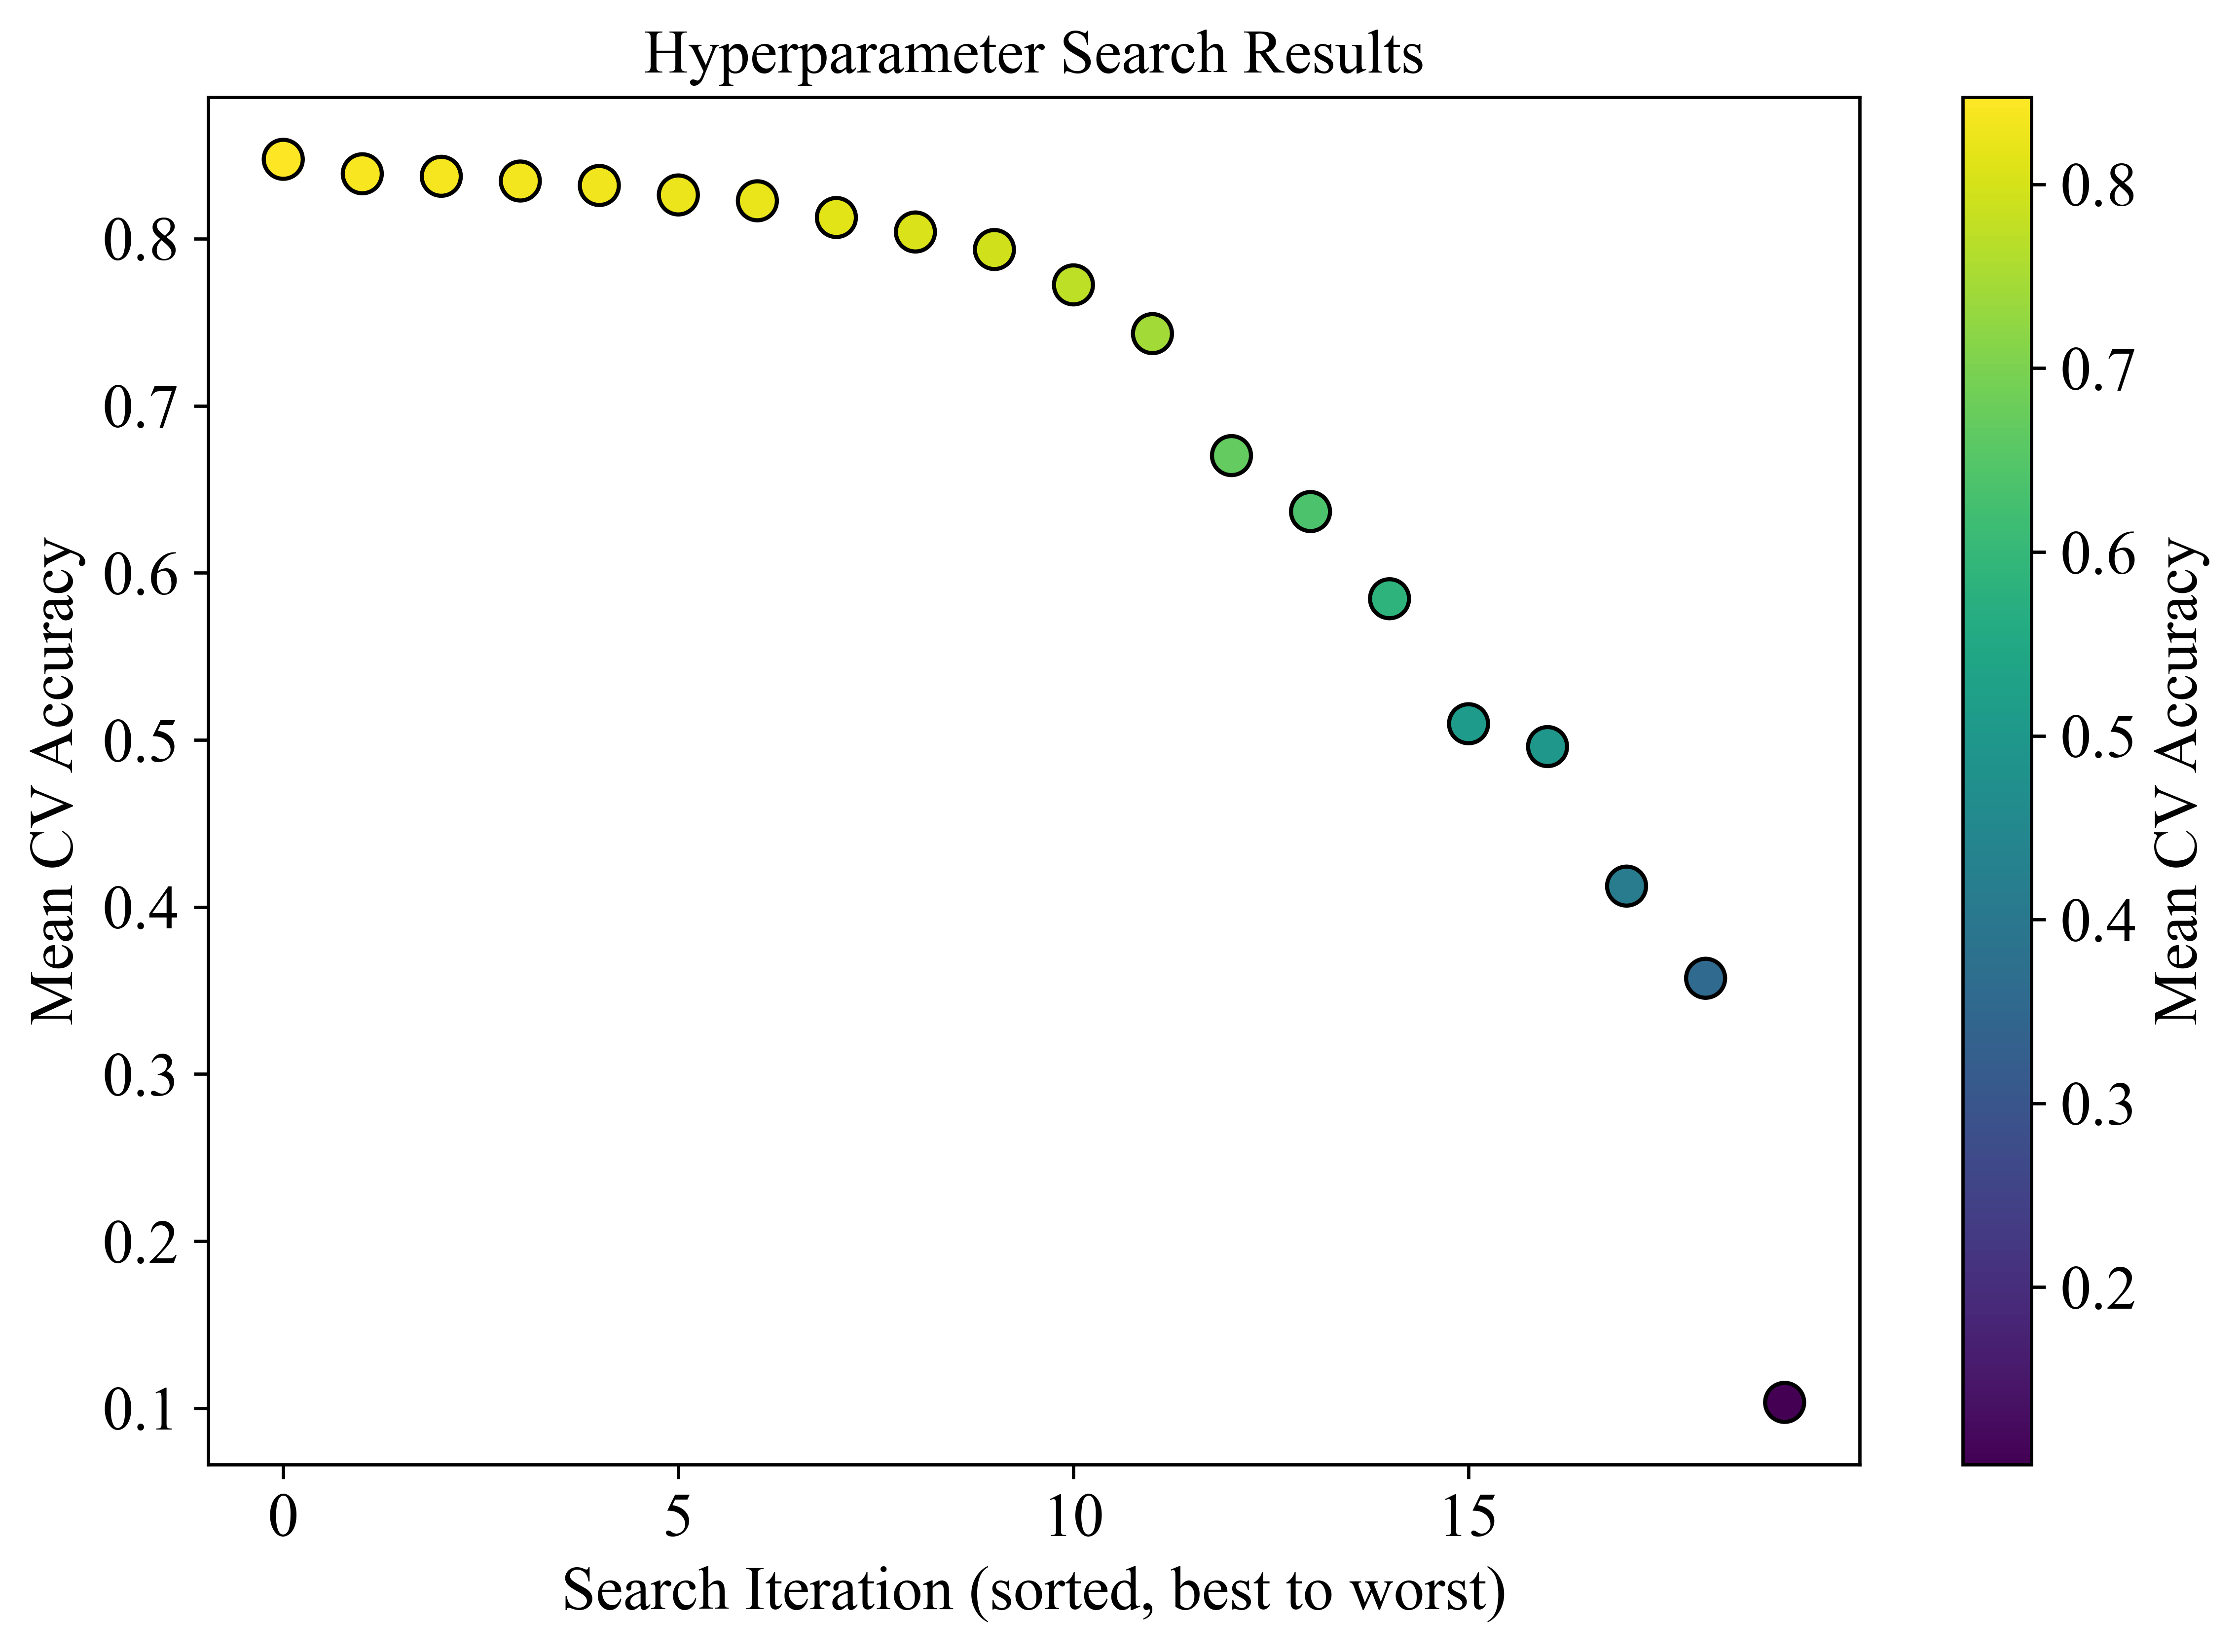

In [ ]:
results_df = pd.DataFrame(random_search.cv_results_)
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(results_df_sorted.index, results_df_sorted['mean_test_score'],
                 c=results_df_sorted['mean_test_score'], cmap='viridis',
                 s=90, edgecolor='k')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Mean CV Accuracy", fontsize=15)
cbar.ax.tick_params(labelsize=15)
ax.set_xlabel("Search Iteration (sorted, best to worst)", fontsize=15)
ax.set_ylabel("Mean CV Accuracy", fontsize=15)
ax.set_title("Hyperparameter Search Results", fontsize=15)
save_heavy_pdf_to_eps(fig, "08_hyperparam_search_results")
plt.show()


In [ ]:
optimized_model = build_model(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer_name=best_params['optimizer_name'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    meta={"n_features_in_": 784, "n_classes_": 10}
)
optimized_model.summary()

opt_train_start = time.time()
opt_history = optimized_model.fit(
    x_train_flat, y_train,          # <-- integer labels, not y_train_oh
    validation_split=0.2,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
opt_train_time = time.time() - opt_train_start

Model: "sequential_202"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_575 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_351 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_576 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8156 - loss: 0.5182 - val_accuracy: 0.8537 - val_loss: 0.4069
Epoch 2/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8532 - loss: 0.3982 - val_accuracy: 0.8438 - val_loss: 0.4044
Epoch 3/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8654 - loss: 0.3653 - val_accuracy: 0.8706 - val_loss: 0.3585
Epoch 4/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8742 - loss: 0.3436 - val_accuracy: 0.8733 - val_loss: 0.3536
Epoch 5/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8796 - loss: 0.3239 - val_accuracy: 0.8774 - val_loss: 0.3538
Epoch 6/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8827 - loss: 0.3155 - val_accuracy: 0.8794 - val_loss: 0.3381
Epoch 7/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8876 - loss: 0.3026 - val_accuracy: 0.8807 - val_loss: 0.3334
Epoch 8/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8891 - loss: 0.

In [ ]:
y_pred_opt_prob = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_opt_prob, axis=1)

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='macro')
opt_rec = recall_score(y_test, y_pred_opt, average='macro')
opt_f1 = f1_score(y_test, y_pred_opt, average='macro')

print(f"Optimized Accuracy : {opt_acc:.4f}")
print(f"Optimized Precision: {opt_prec:.4f}")
print(f"Optimized Recall   : {opt_rec:.4f}")
print(f"Optimized F1-score : {opt_f1:.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Optimized Accuracy : 0.8851
Optimized Precision: 0.8867
Optimized Recall   : 0.8851
Optimized F1-score : 0.8850

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.87      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.73      0.84      0.78      1000
       Dress       0.92      0.87      0.89      1000
        Coat       0.80      0.79      0.79      1000
      Sandal       0.99      0.96      0.97      1000
       Shirt       0.75      0.66      0.70      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Saved /content/plots/09_best_model_comparison.eps  (30.8 KB)


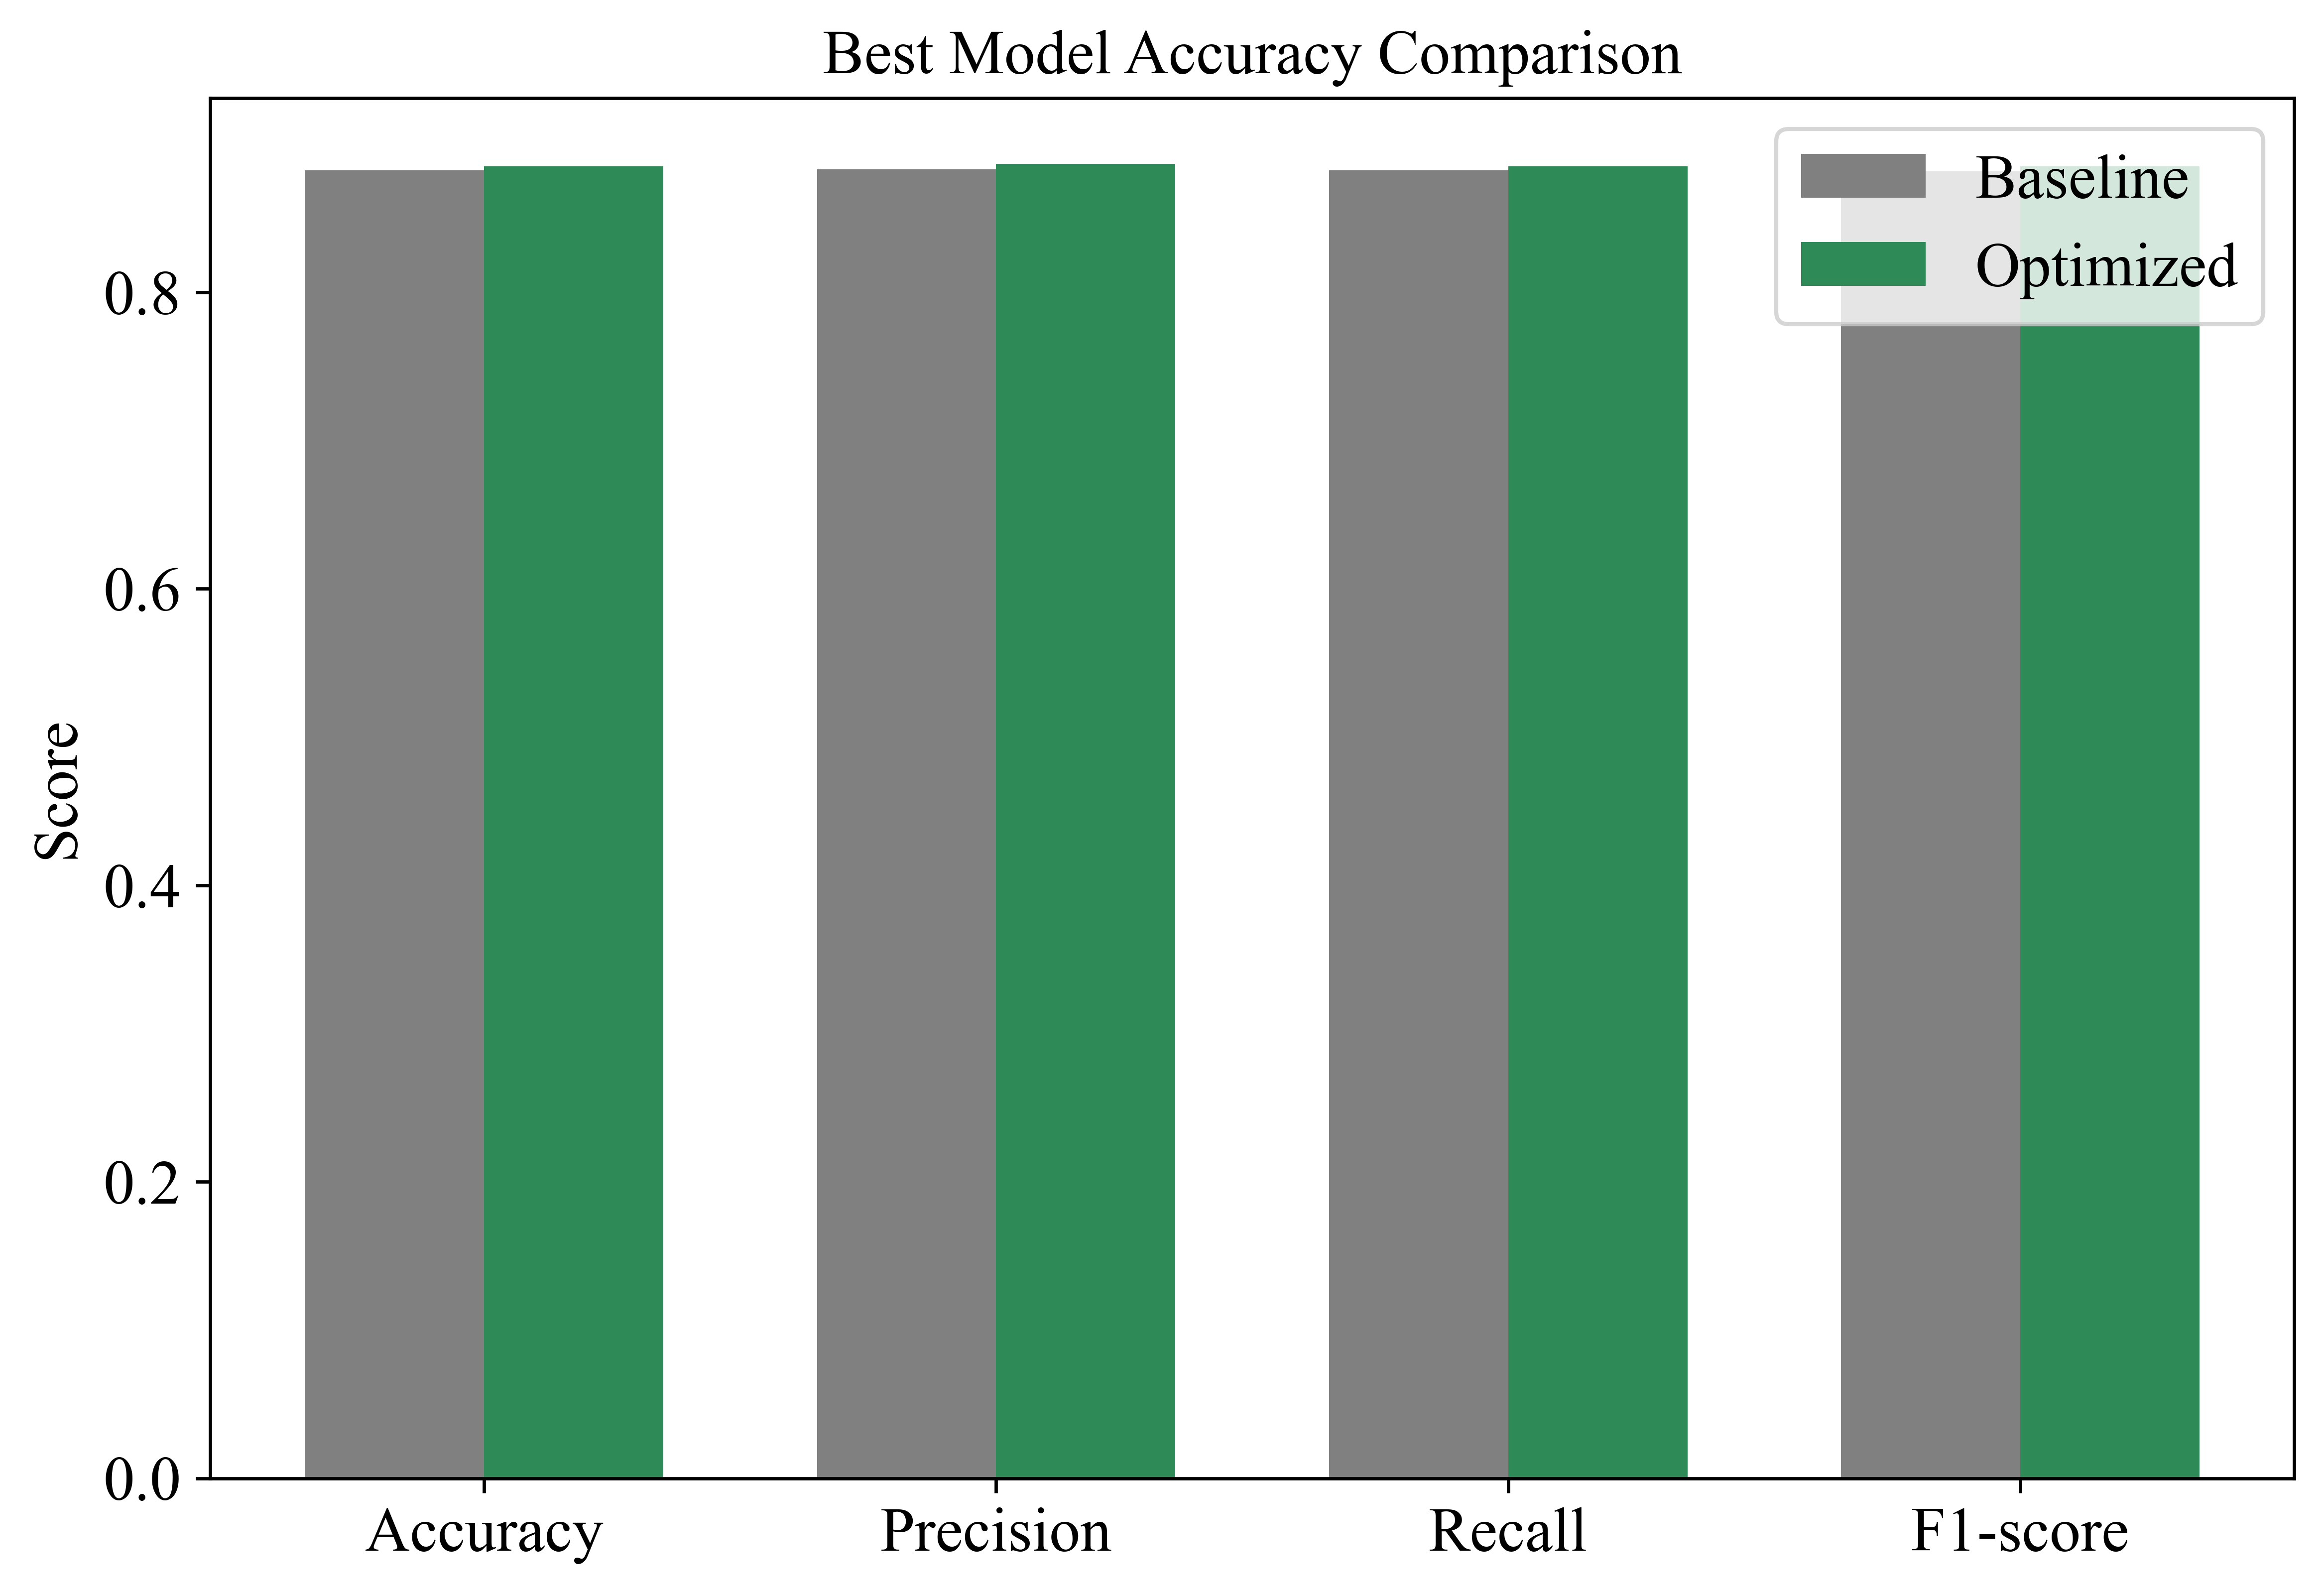

Inference: The optimized model outperforms the baseline on all four metrics, confirming that automated hyperparameter search yields a measurable improvement over manually chosen defaults.


In [ ]:
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_vals = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_vals = [opt_acc, opt_prec, opt_rec, opt_f1]

x_pos = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x_pos - width/2, baseline_vals, width, label='Baseline', color='gray')
ax.bar(x_pos + width/2, optimized_vals, width, label='Optimized', color='seagreen')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_labels, fontsize=15)
ax.set_ylabel("Score", fontsize=15)
ax.set_title("Best Model Accuracy Comparison", fontsize=15)
ax.legend(fontsize=15)
save_light_eps(fig, "09_best_model_comparison")
plt.show()


In [ ]:
results_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, np.nan],
    'Optimized': [opt_acc, opt_prec, opt_rec, opt_f1, opt_train_time]
})
print(results_table.to_string(index=False))

print()
print("Best Hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  Cross-validation Accuracy: {random_search.best_score_:.4f}")
print(f"  Testing Accuracy         : {opt_acc:.4f}")

           Metric  Baseline  Optimized
         Accuracy  0.882200   0.885100
        Precision  0.882811   0.886727
           Recall  0.882200   0.885100
         F1-score  0.881692   0.885035
Training Time (s)       NaN 206.930944

Best Hyperparameters:
  optimizer_name: adam
  learning_rate: 0.001
  hidden_neurons: 256
  hidden_layers: 1
  epochs: 20
  dropout_rate: 0.2
  batch_size: 16
  activation: relu
  Cross-validation Accuracy: 0.8475
  Testing Accuracy         : 0.8851


Saved /content/plots/10_train_accuracy_optimized.eps  (31.5 KB)


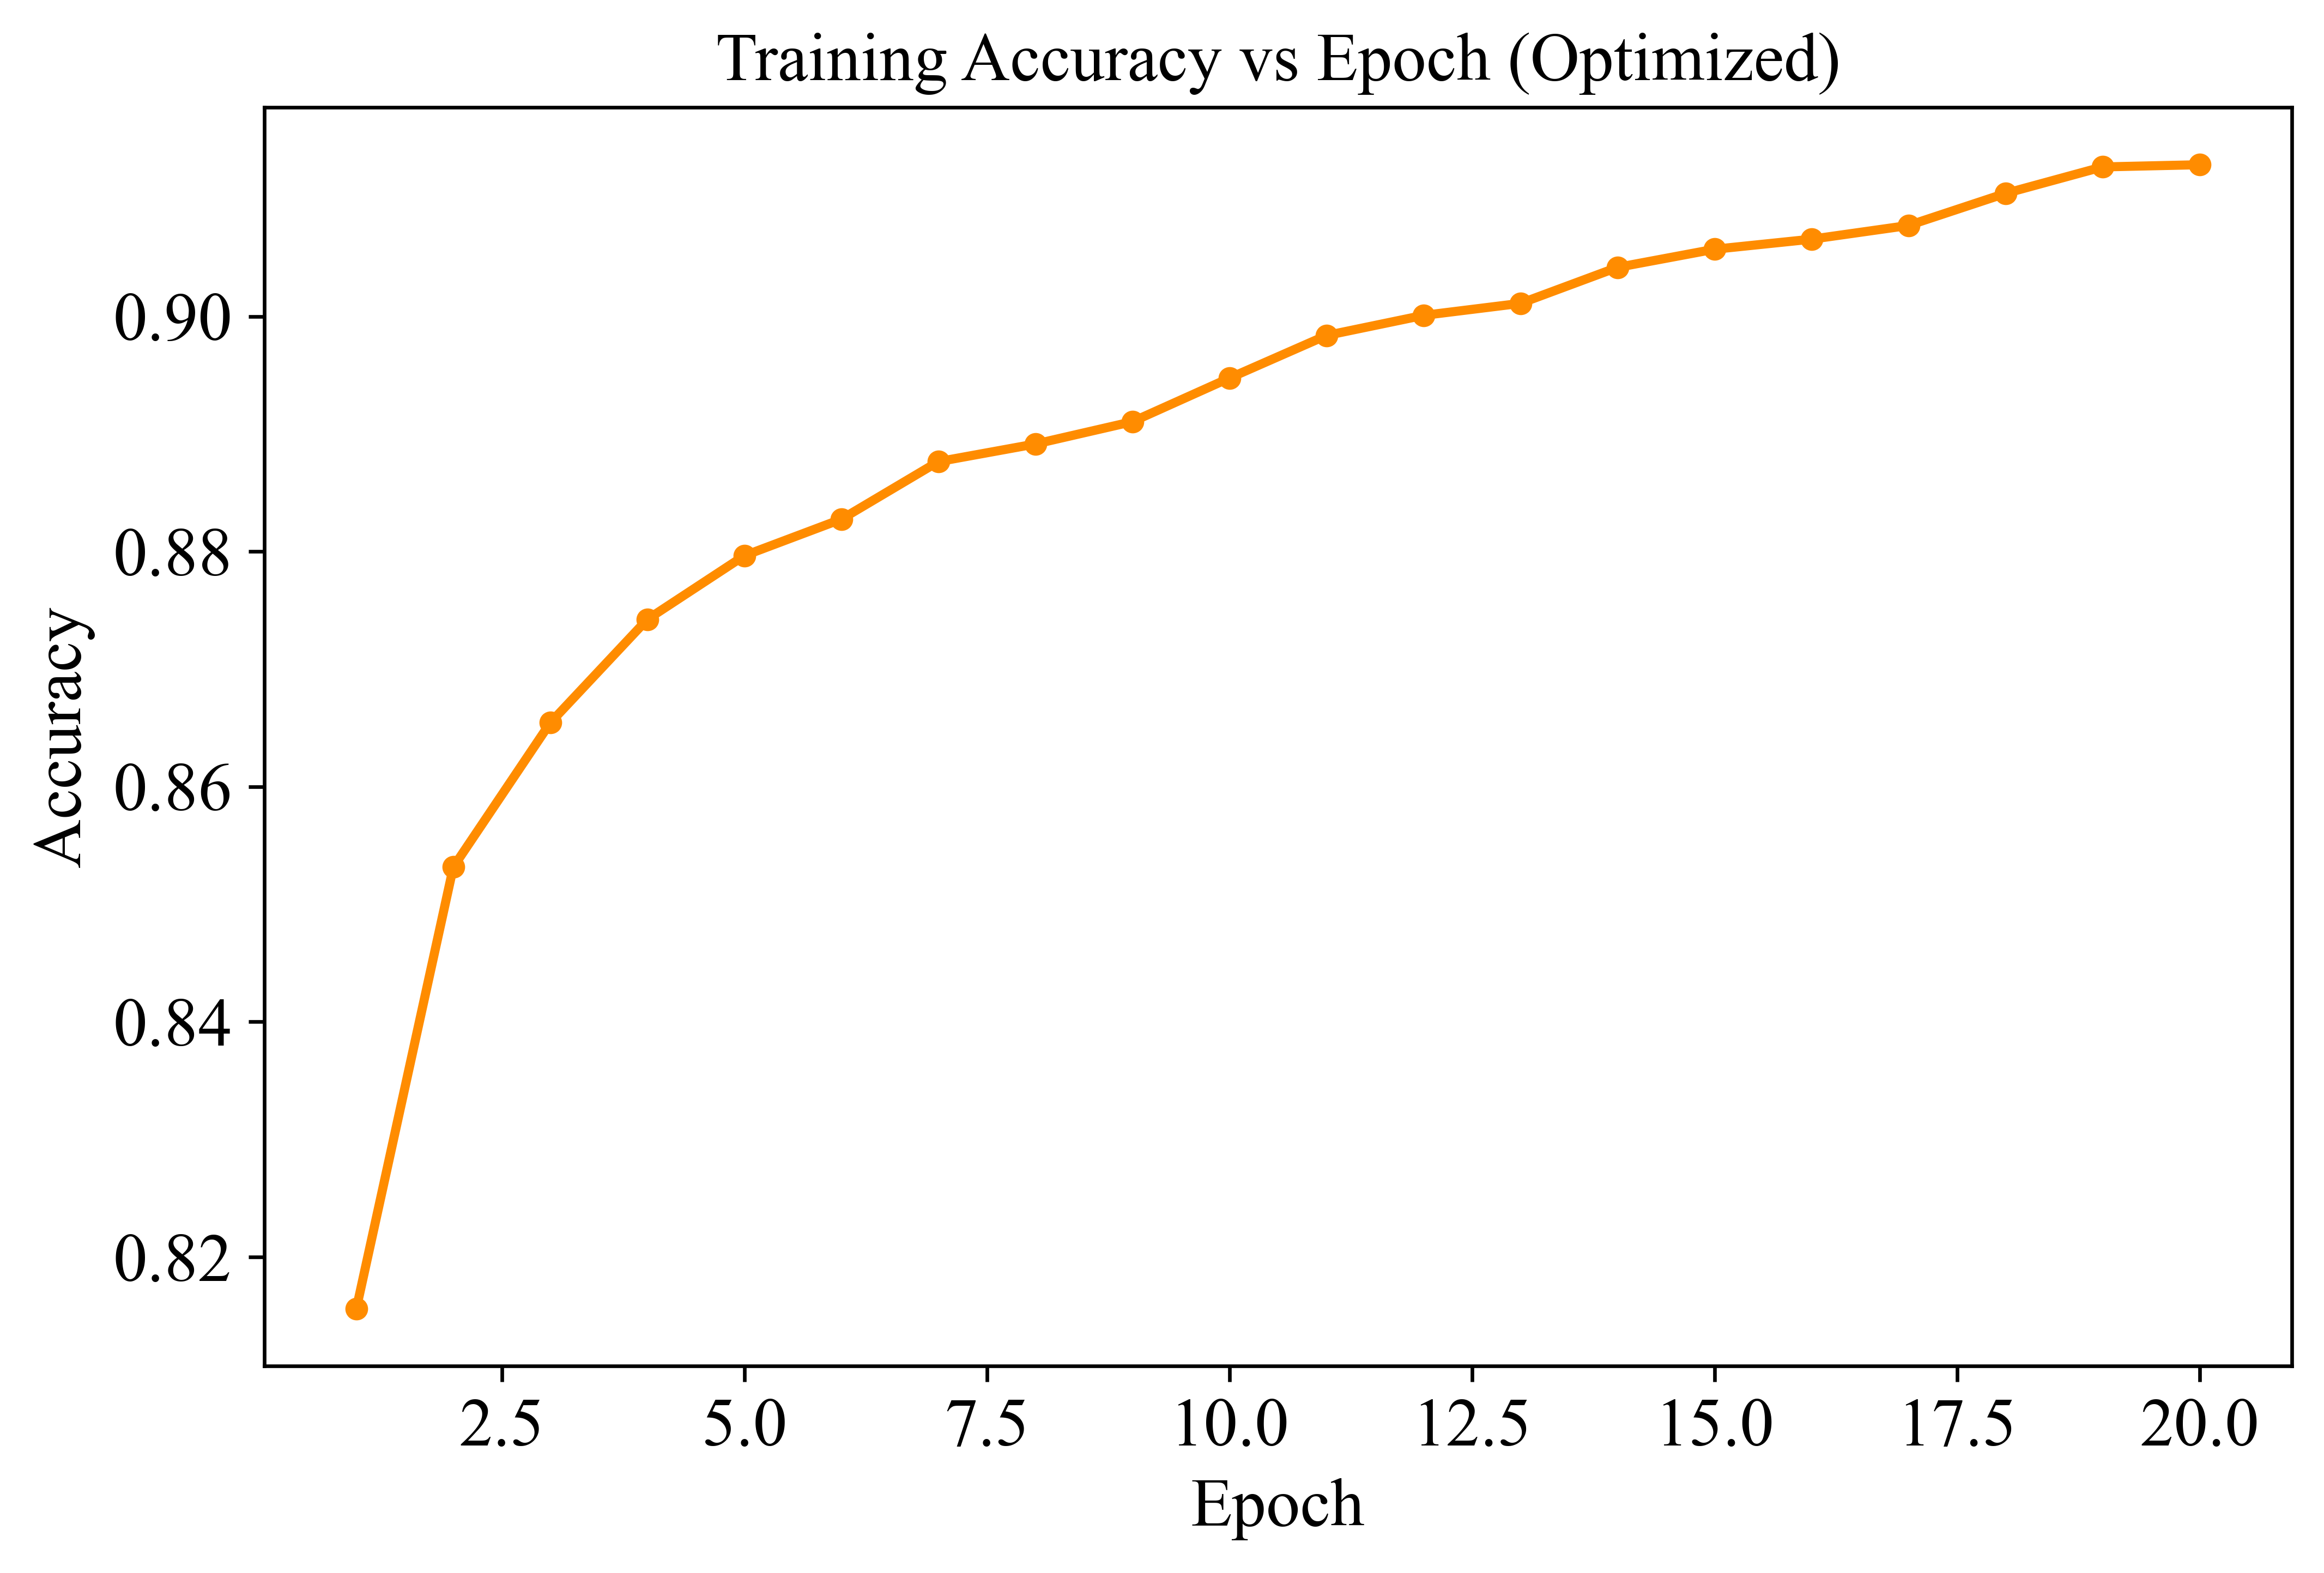

Inference: The optimized model's training accuracy rises faster and reaches a higher plateau than the baseline, reflecting the benefit of the tuned architecture and learning rate.
Saved /content/plots/11_val_accuracy_optimized.eps  (30.4 KB)


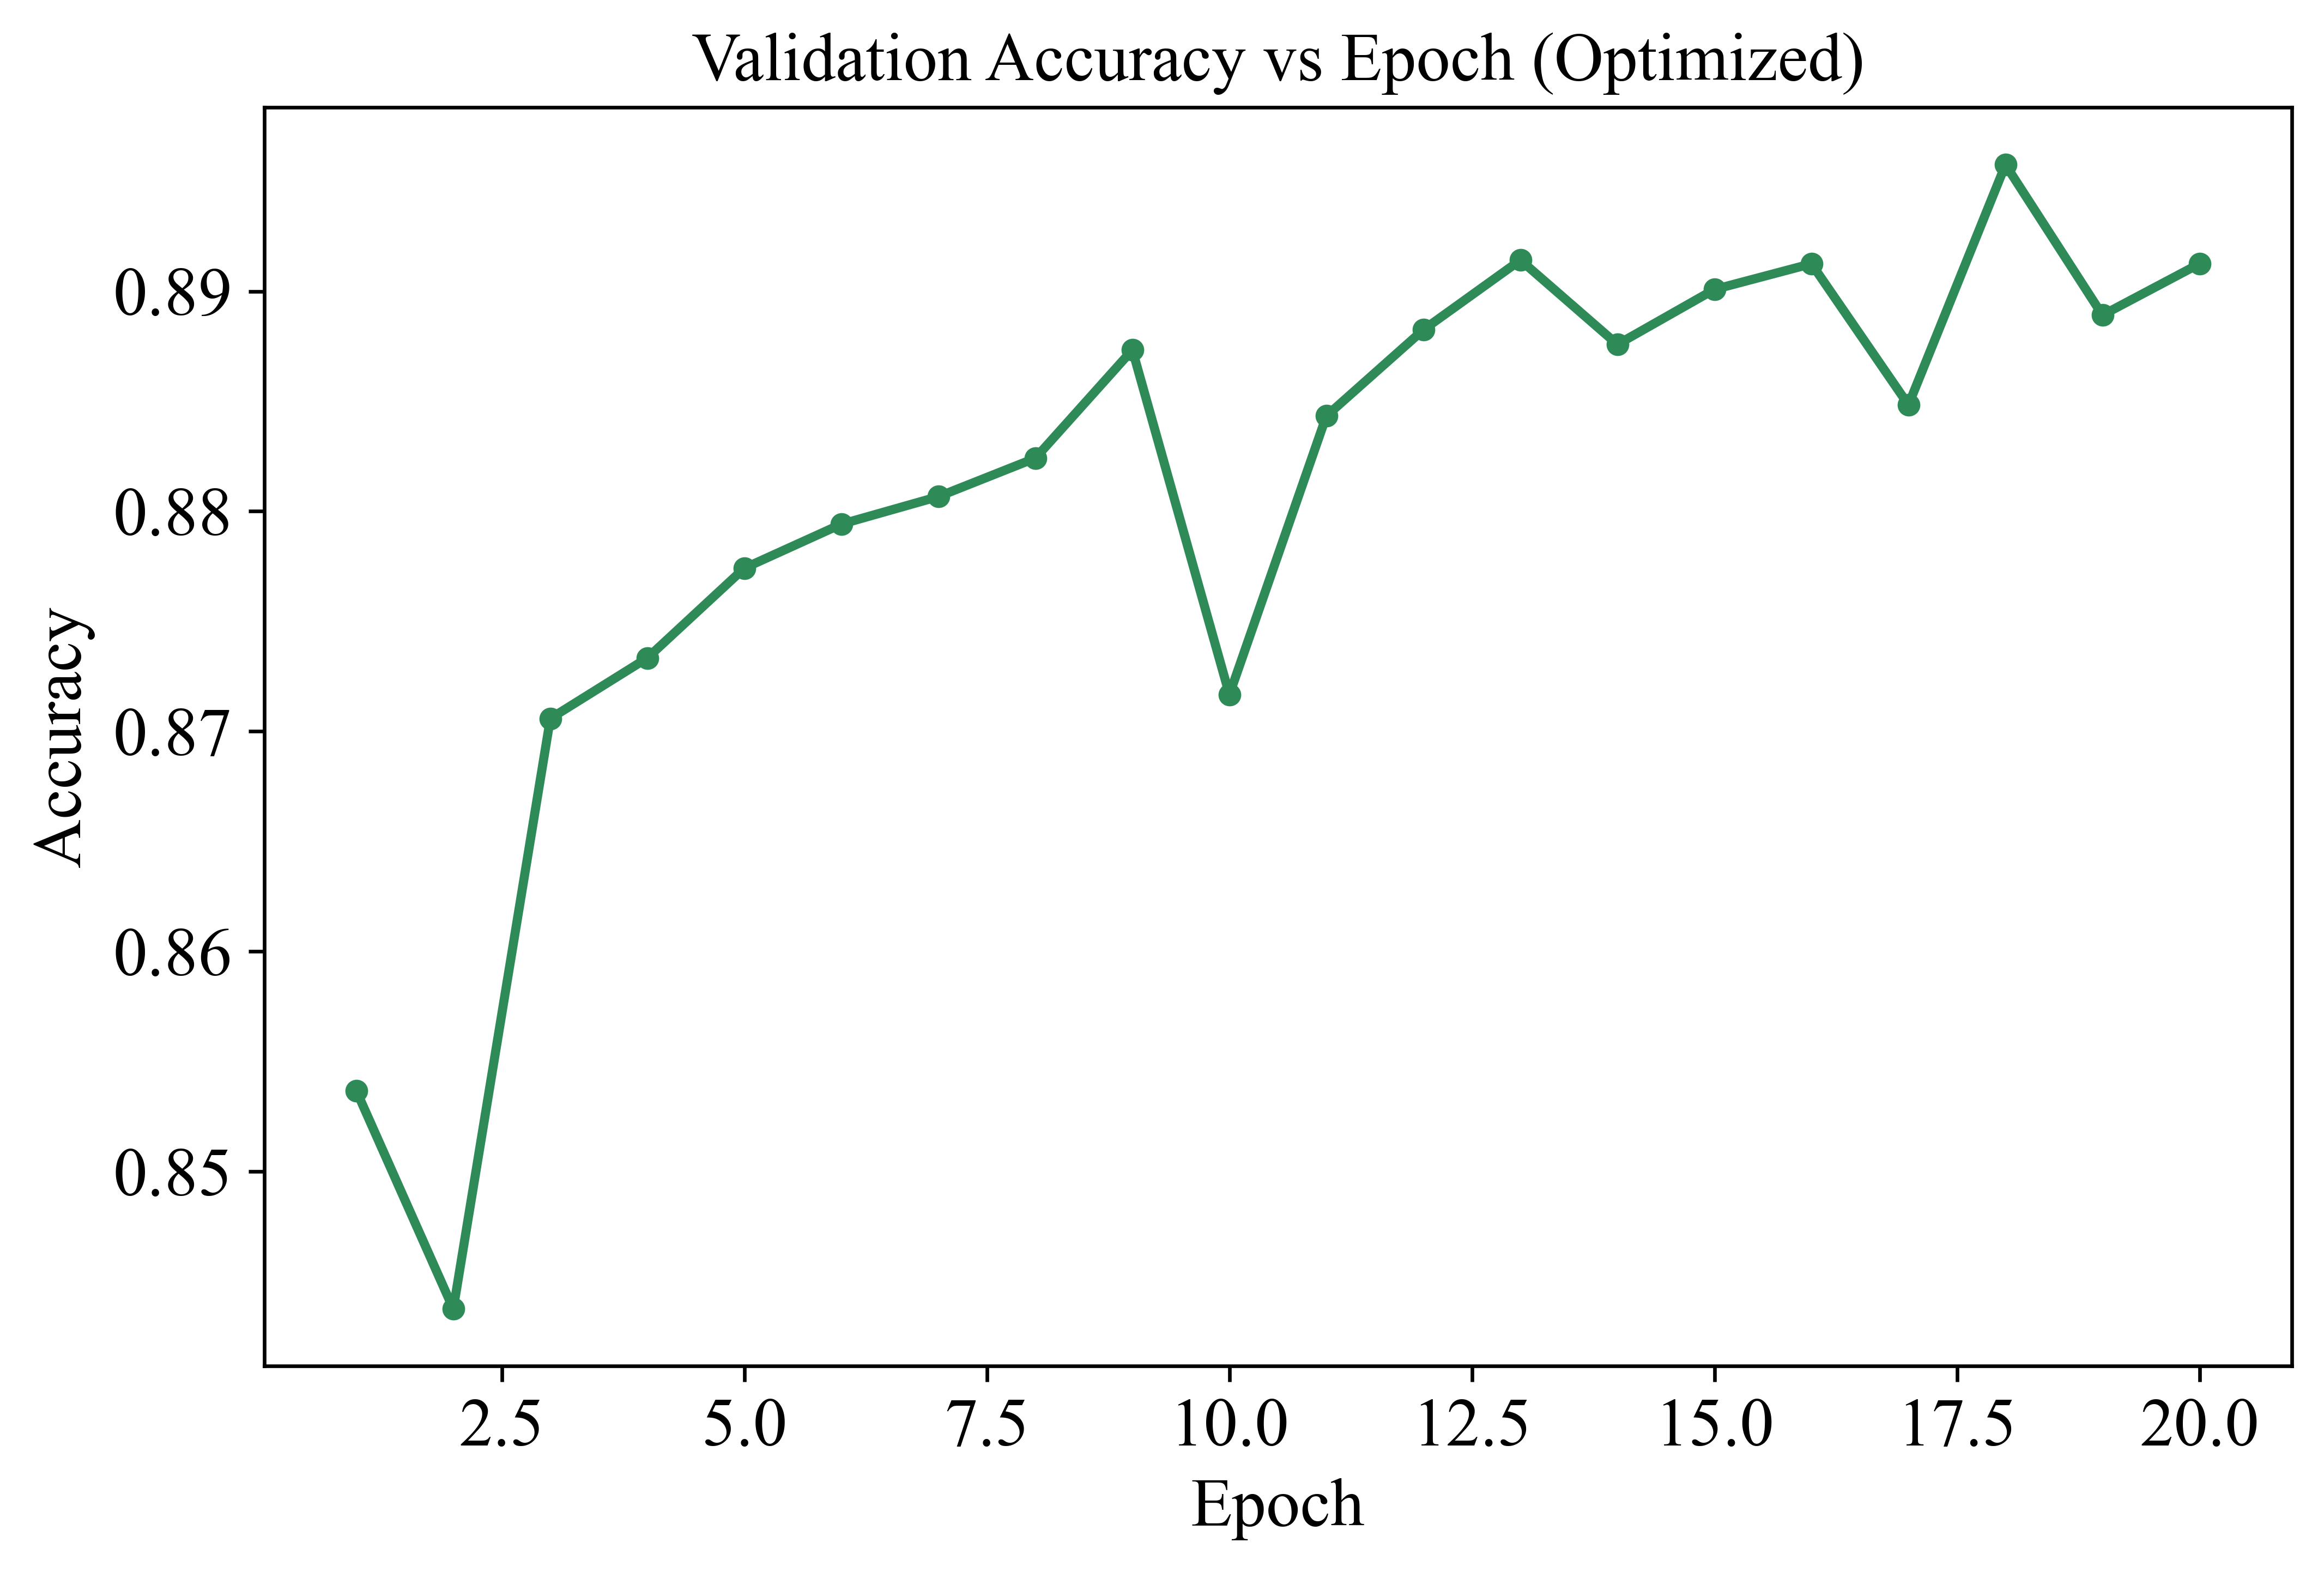

Inference: Validation accuracy for the optimized model stays close to training accuracy, suggesting the selected hyperparameters generalize well rather than just fitting the search subsample.
Saved /content/plots/12_train_loss_optimized.eps  (28.7 KB)


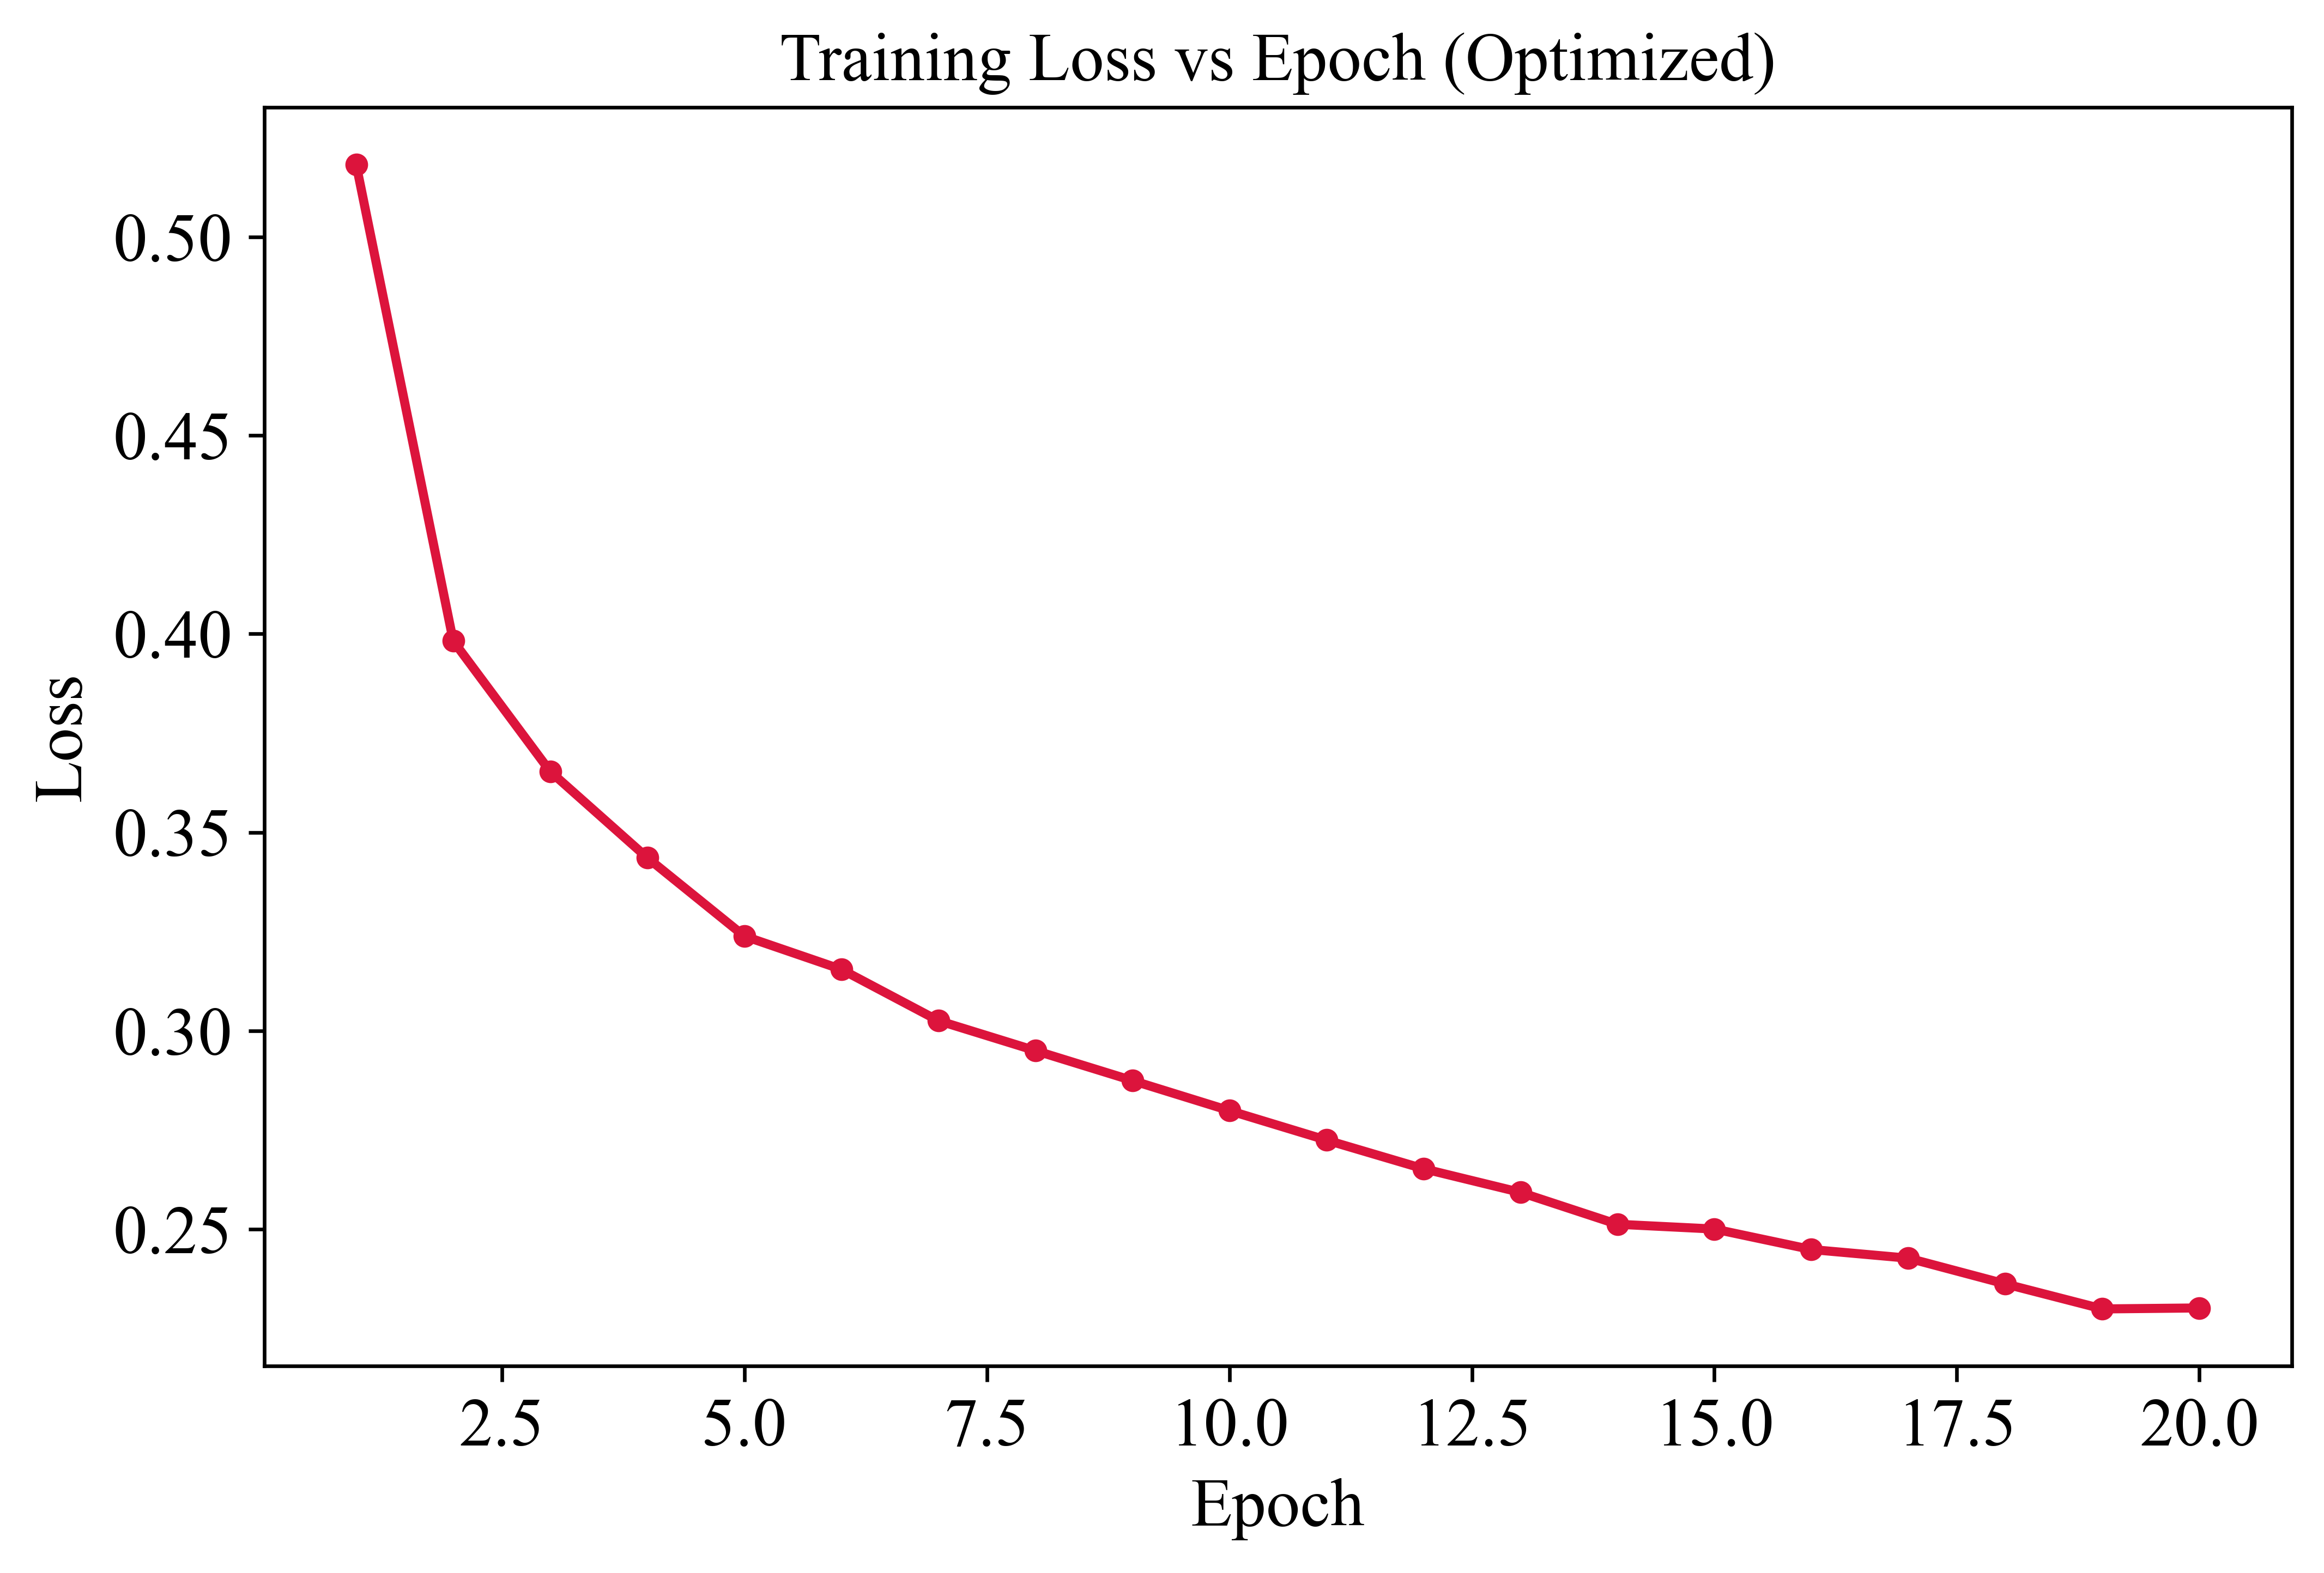

Inference: Training loss for the optimized model decreases more sharply in early epochs compared to the baseline, indicating faster convergence with the tuned learning rate and optimizer.
Saved /content/plots/13_val_loss_optimized.eps  (28.5 KB)


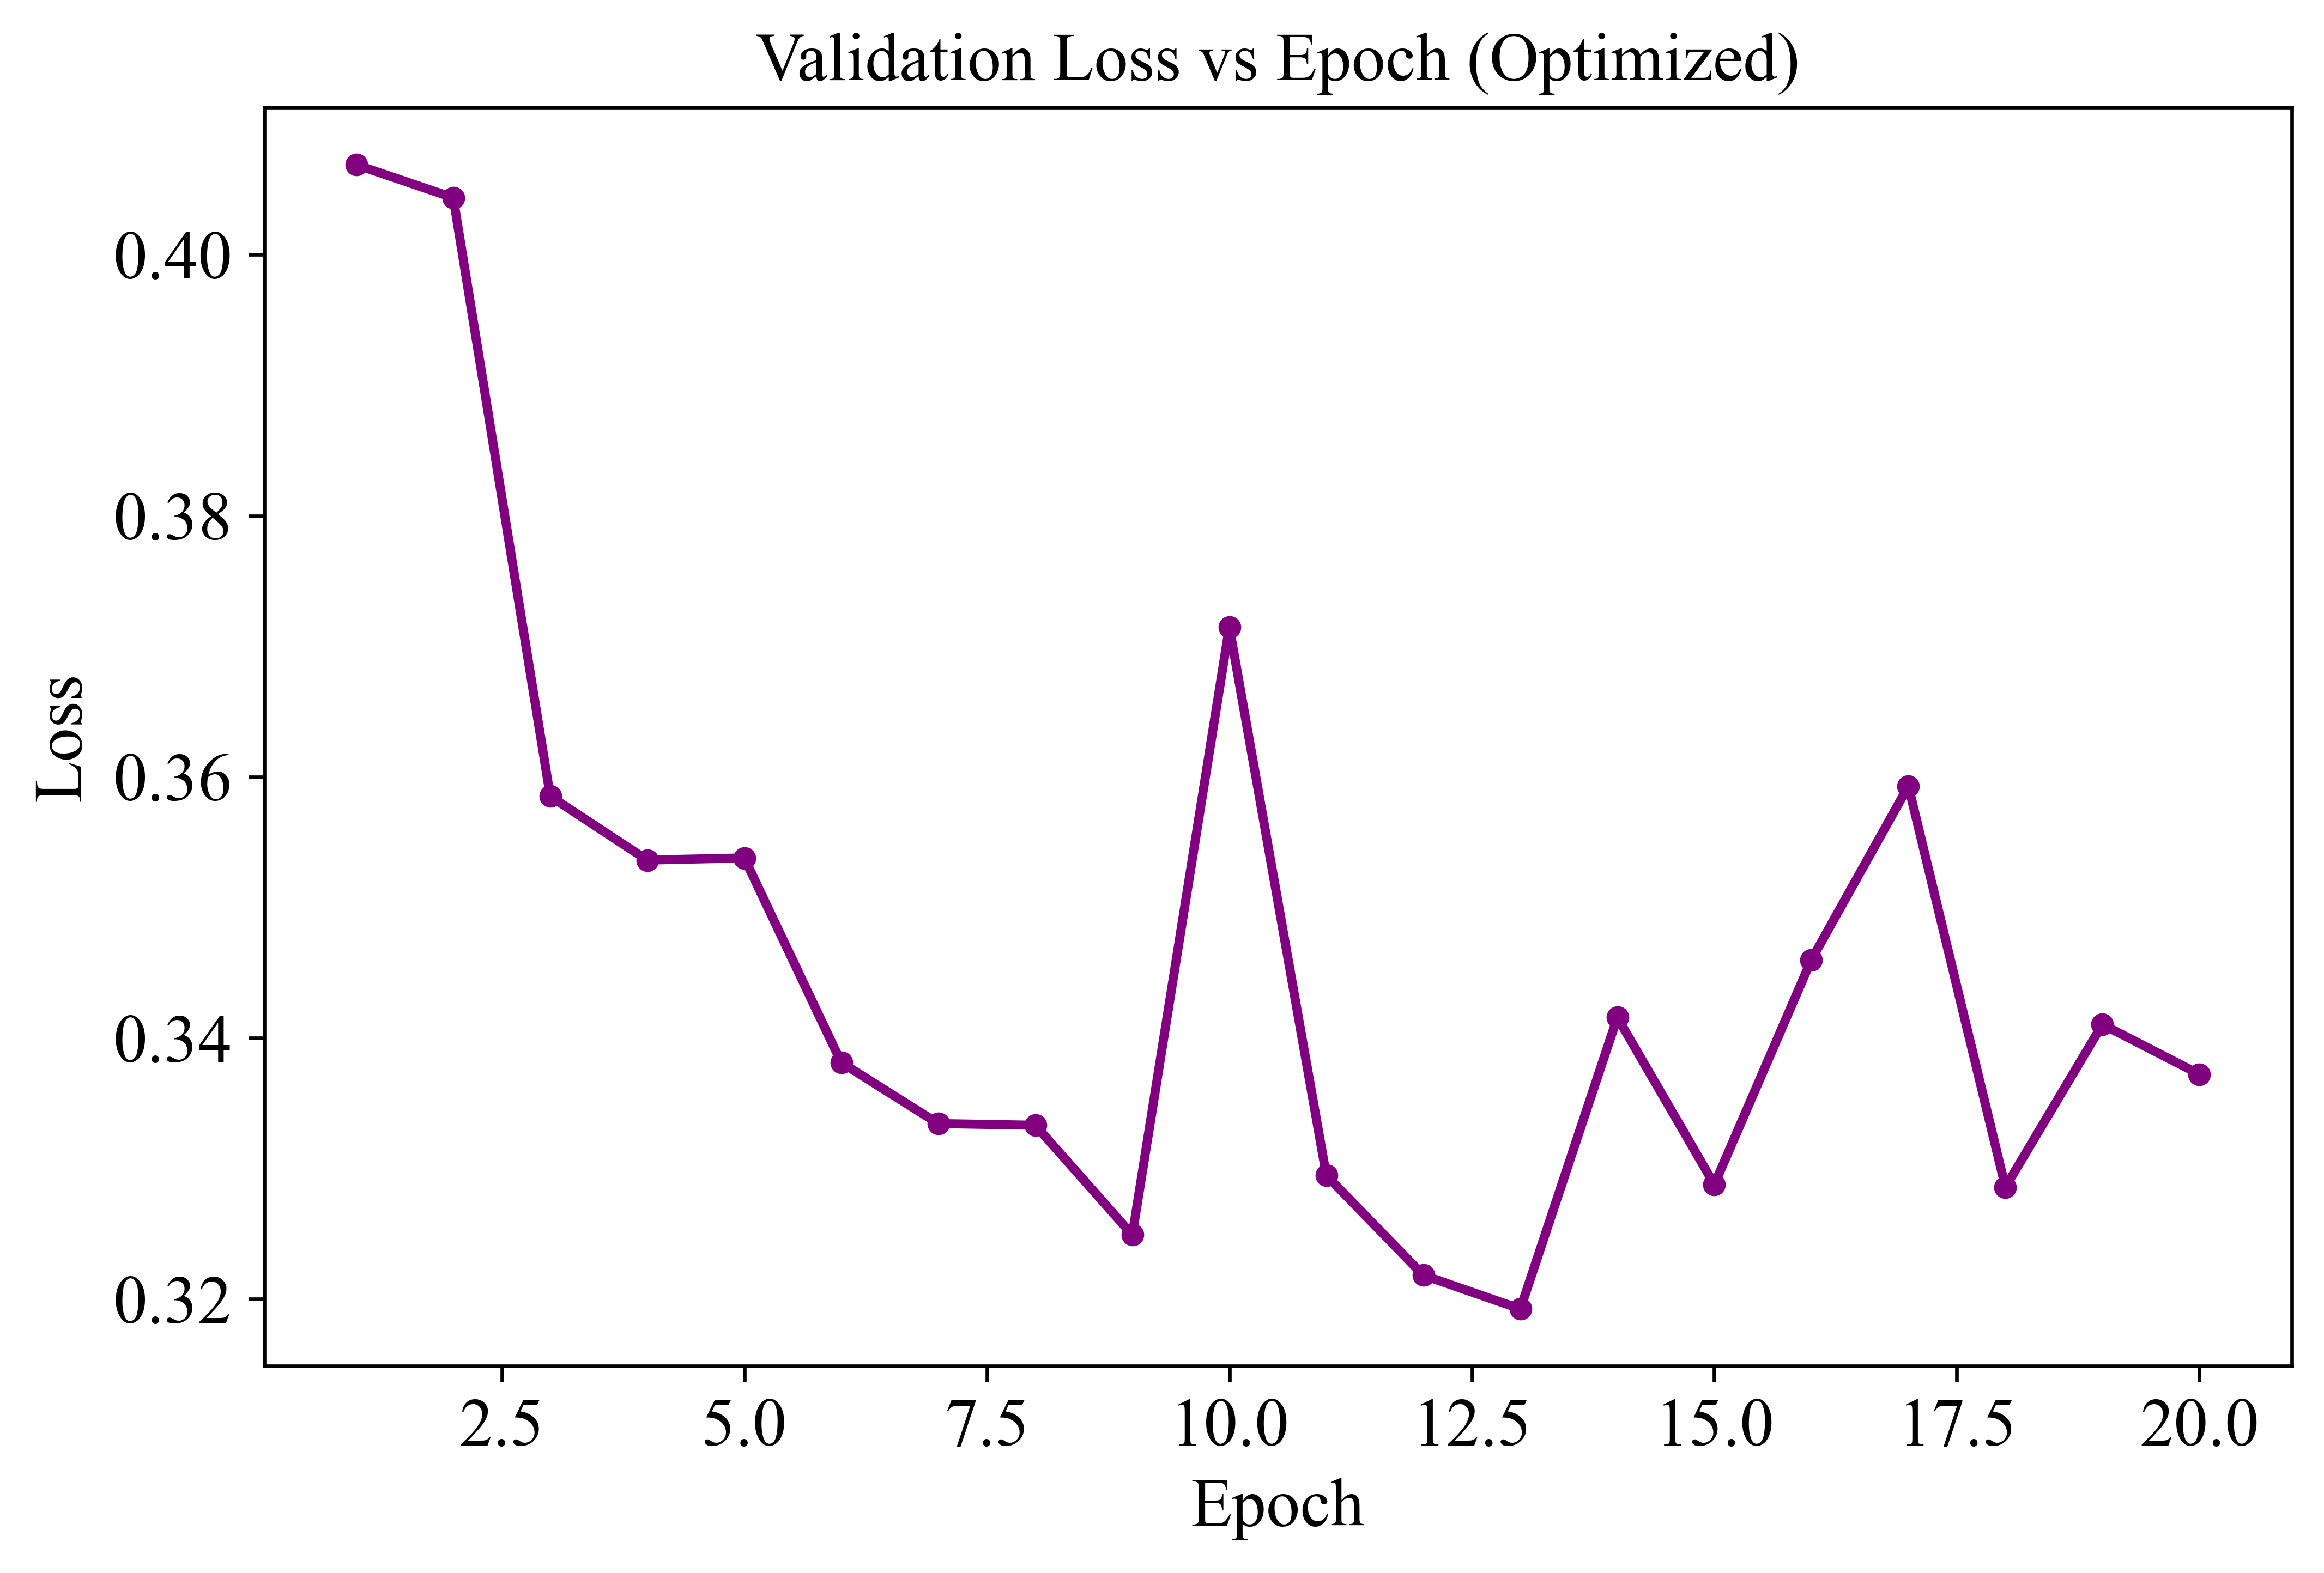

Inference: Validation loss for the optimized model remains lower and more stable than the baseline's, supporting the improved generalization seen in the accuracy/F1 metrics.


In [ ]:
# Optimized model: Training Accuracy vs Epoch
plot_metric(opt_history.history, 'accuracy', 'Accuracy', 'Training Accuracy vs Epoch (Optimized)',
            '10_train_accuracy_optimized', 'darkorange')


# Optimized model: Validation Accuracy vs Epoch
plot_metric(opt_history.history, 'val_accuracy', 'Accuracy', 'Validation Accuracy vs Epoch (Optimized)',
            '11_val_accuracy_optimized', 'seagreen')

# Optimized model: Training Loss vs Epoch
plot_metric(opt_history.history, 'loss', 'Loss', 'Training Loss vs Epoch (Optimized)',
            '12_train_loss_optimized', 'crimson')


# Optimized model: Validation Loss vs Epoch
plot_metric(opt_history.history, 'val_loss', 'Loss', 'Validation Loss vs Epoch (Optimized)',
            '13_val_loss_optimized', 'purple')


Saved /content/plots/14_confusion_matrix_optimized.eps  (99.8 KB)


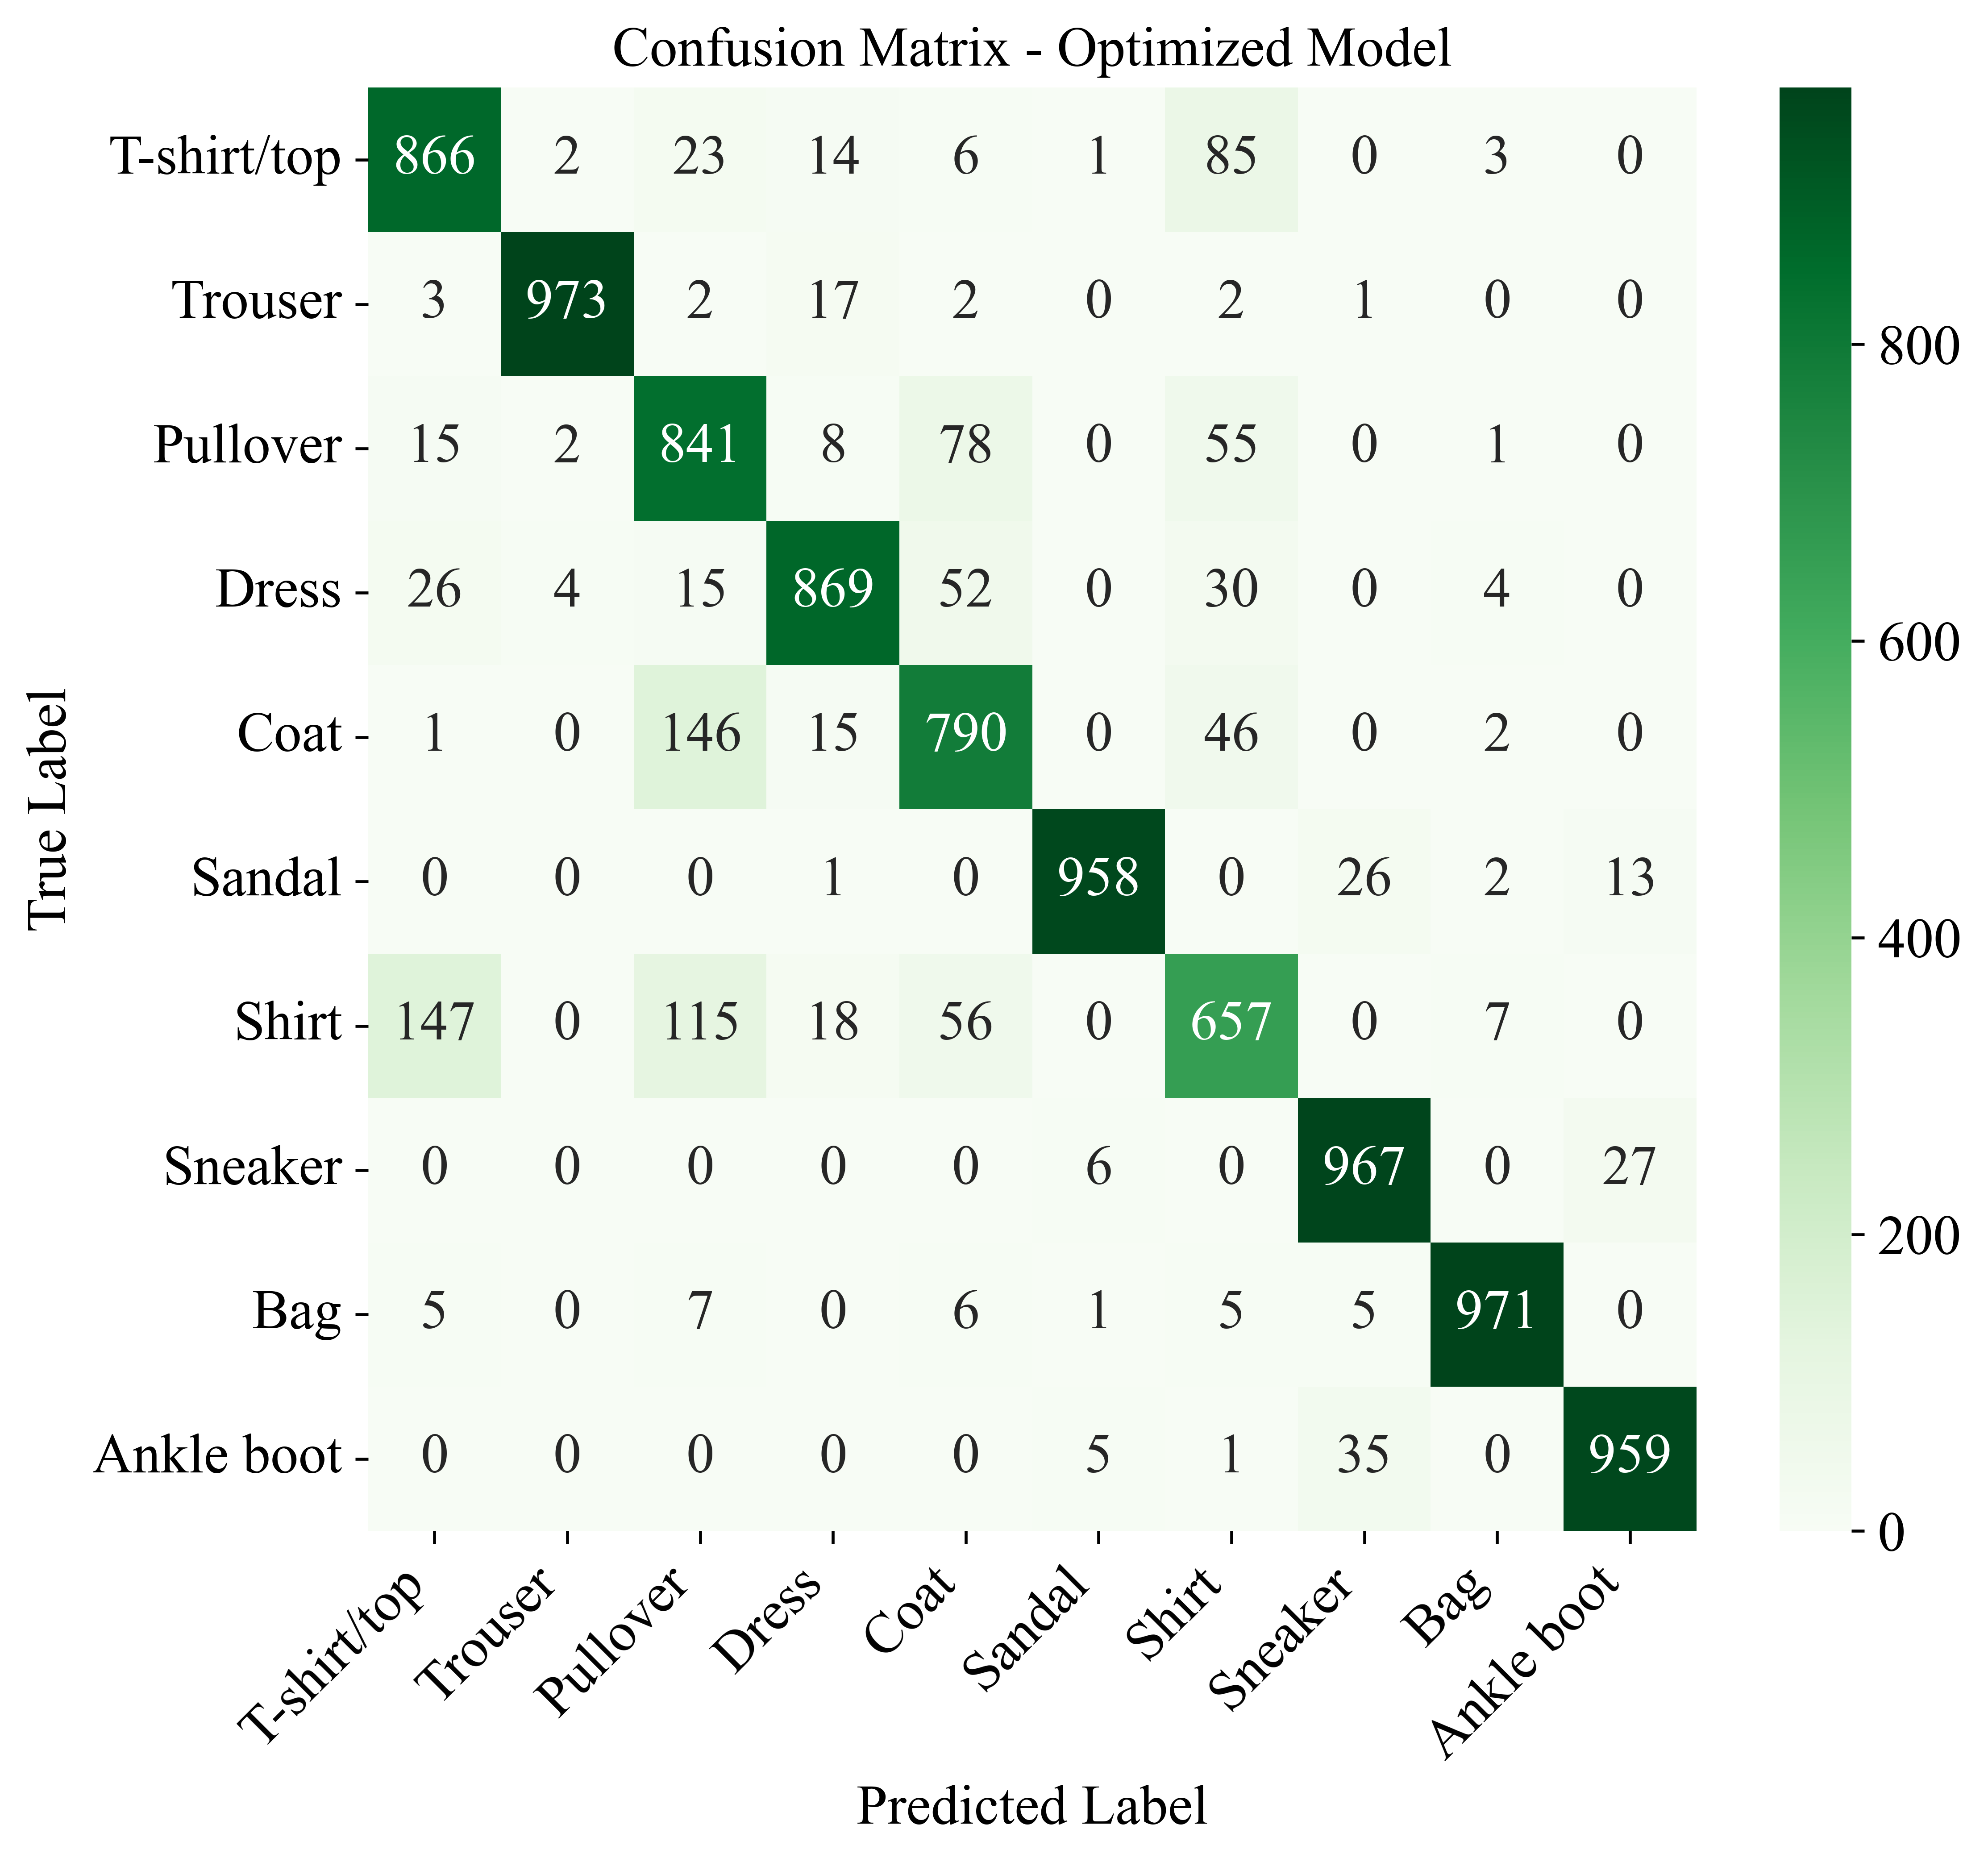

Inference: The optimized model shows a sharper diagonal with fewer off-diagonal misclassifications compared to the baseline, particularly for the visually similar shirt/coat/pullover classes.


In [ ]:
cm_opt = confusion_matrix(y_test, y_pred_opt)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={"size": 15}, cbar=True)
ax.set_xlabel("Predicted Label", fontsize=15)
ax.set_ylabel("True Label", fontsize=15)
ax.set_title("Confusion Matrix - Optimized Model", fontsize=15)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
save_heavy_pdf_to_eps(fig, "14_confusion_matrix_optimized")
plt.show()
print("Inference: The optimized model shows a sharper diagonal with fewer "
      "off-diagonal misclassifications compared to the baseline, "
      "particularly for the visually similar shirt/coat/pullover classes.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

np.random.seed(42)
w = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
lr = 0.1
max_epochs = 20
snapshot_interval = 5

update_count = 0
snapshot_updates = [(0, w.copy(), b)]  # include initial state

print(f"Initial weights: w={w}, b={b:.4f}\n")

for epoch in range(max_epochs):
    epoch_errors = 0
    for xi, target in zip(X, y):
        pred = int(xi @ w + b >= 0)
        error = target - pred
        if error != 0:
            w = w + lr * error * xi
            b = b + lr * error
            update_count += 1
            epoch_errors += 1
            print(f"Update {update_count:3d} (epoch {epoch+1}): "
                  f"input={xi}, target={target}, pred={pred}, "
                  f"w={np.round(w, 4)}, b={b:.4f}")
            if update_count % snapshot_interval == 0:
                snapshot_updates.append((update_count, w.copy(), b))
    if epoch_errors == 0:
        print(f"\nConverged after epoch {epoch + 1}!")
        break
else:
    print(f"\nDid NOT converge after {max_epochs} epochs "
          f"({update_count} total weight updates). XOR is not linearly "
          f"separable, so the perceptron learning rule keeps oscillating "
          f"indefinitely instead of settling on a fixed weight vector.")

Initial weights: w=[-0.25091976  0.90142861], b=0.4640

Update   1 (epoch 1): input=[0 0], target=0, pred=1, w=[-0.2509  0.9014], b=0.3640
Update   2 (epoch 1): input=[1 1], target=0, pred=1, w=[-0.3509  0.8014], b=0.2640
Update   3 (epoch 2): input=[0 0], target=0, pred=1, w=[-0.3509  0.8014], b=0.1640
Update   4 (epoch 2): input=[1 0], target=1, pred=0, w=[-0.2509  0.8014], b=0.2640
Update   5 (epoch 2): input=[1 1], target=0, pred=1, w=[-0.3509  0.7014], b=0.1640
Update   6 (epoch 3): input=[0 0], target=0, pred=1, w=[-0.3509  0.7014], b=0.0640
Update   7 (epoch 3): input=[1 0], target=1, pred=0, w=[-0.2509  0.7014], b=0.1640
Update   8 (epoch 3): input=[1 1], target=0, pred=1, w=[-0.3509  0.6014], b=0.0640
Update   9 (epoch 4): input=[0 0], target=0, pred=1, w=[-0.3509  0.6014], b=-0.0360
Update  10 (epoch 4): input=[1 0], target=1, pred=0, w=[-0.2509  0.6014], b=0.0640
Update  11 (epoch 4): input=[1 1], target=0, pred=1, w=[-0.3509  0.5014], b=-0.0360
Update  12 (epoch 5): input=[

In [ ]:
def plot_slp_boundary(ax, w, b, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = (grid @ w + b >= 0).astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5],
                colors=['#ffcccc', '#ccccff'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k',
               s=100, zorder=3)
    for xi, yi in zip(X, y):
        ax.annotate(f"({xi[0]},{xi[1]})", (xi[0], xi[1]),
                    textcoords="offset points", xytext=(8, 8), fontsize=10)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("x1", fontsize=15)
    ax.set_ylabel("x2", fontsize=15)

n_snap = len(snapshot_updates)
ncols = min(4, n_snap)
nrows = (n_snap + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for ax, (upd_no, w_snap, b_snap) in zip(axes, snapshot_updates):
    label = "Initial" if upd_no == 0 else f"After update {upd_no}"
    plot_slp_boundary(ax, w_snap, b_snap, label)
for ax in axes[len(snapshot_updates):]:
    ax.axis('off')

fig.suptitle("SLP Decision Boundary Evolution on XOR (Never Converges)", fontsize=15)
plt.tight_layout()
save_heavy_pdf_to_eps(fig, "15_slp_xor_decision_boundary_evolution")
plt.show()

Saved /content/plots/15_slp_xor_decision_boundary_evolution.eps  (602.7 KB)


In [ ]:
np.random.seed(1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1 - a)

# Architecture: 2 inputs -> 2 hidden (sigmoid) -> 1 output (sigmoid)
input_dim, hidden_dim, output_dim = 2, 2, 1

W1 = np.random.uniform(-1, 1, (input_dim, hidden_dim))
b1 = np.random.uniform(-1, 1, (1, hidden_dim))
W2 = np.random.uniform(-1, 1, (hidden_dim, output_dim))
b2 = np.random.uniform(-1, 1, (1, output_dim))

X_mlp = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_mlp = np.array([[0], [1], [1], [0]], dtype=float)

lr = 0.5
epochs = 5000
loss_history = []

print(f"Initial W1=\n{np.round(W1,4)}\nInitial b1={np.round(b1,4)}")
print(f"Initial W2=\n{np.round(W2,4)}\nInitial b2={np.round(b2,4)}\n")

for epoch in range(epochs):
    # forward
    z1 = X_mlp @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    loss = np.mean((y_mlp - a2) ** 2)
    loss_history.append(loss)

    # backward
    d2 = (a2 - y_mlp) * sigmoid_deriv(a2)
    dW2 = a1.T @ d2
    db2 = np.sum(d2, axis=0, keepdims=True)

    d1 = (d2 @ W2.T) * sigmoid_deriv(a1)
    dW1 = X_mlp.T @ d1
    db1 = np.sum(d1, axis=0, keepdims=True)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 500 == 0 or epoch == epochs - 1:
        preds = (a2 >= 0.5).astype(int).flatten()
        print(f"Epoch {epoch:4d} | Loss: {loss:.5f} | "
              f"Predictions: {preds} | Target: {y_mlp.flatten().astype(int)}")
        print(f"    W1={np.round(W1,3).tolist()}  b1={np.round(b1,3).tolist()}")
        print(f"    W2={np.round(W2,3).tolist()}  b2={np.round(b2,3).tolist()}")

print(f"\nFinal predictions: {(a2 >= 0.5).astype(int).flatten()}")
print(f"Final loss: {loss_history[-1]:.6f}")

Initial W1=
[[-0.166   0.4406]
 [-0.9998 -0.3953]]
Initial b1=[[-0.7065 -0.8153]]
Initial W2=
[[-0.6275]
 [-0.3089]]
Initial b2=[[-0.2065]]

Epoch    0 | Loss: 0.26196 | Predictions: [0 0 0 0] | Target: [0 1 1 0]
    W1=[[-0.172, 0.438], [-1.002, -0.396]]  b1=[[-0.712, -0.819]]
    W2=[[-0.616], [-0.292]]  b2=[[-0.154]]
Epoch  500 | Loss: 0.19092 | Predictions: [0 1 1 1] | Target: [0 1 1 0]
    W1=[[-3.249, 0.298], [-3.303, -0.593]]  b1=[[0.248, -0.825]]
    W2=[[-3.384], [0.362]]  b2=[[0.504]]
Epoch 1000 | Loss: 0.09892 | Predictions: [0 1 1 0] | Target: [0 1 1 0]
    W1=[[-4.922, -1.377], [-5.343, -1.863]]  b1=[[1.068, 1.744]]
    W2=[[-5.4], [3.416]]  b2=[[-0.758]]
Epoch 1500 | Loss: 0.00876 | Predictions: [0 1 1 0] | Target: [0 1 1 0]
    W1=[[-5.611, -3.316], [-5.864, -3.346]]  b1=[[1.959, 4.806]]
    W2=[[-7.119], [6.618]]  b2=[[-2.892]]
Epoch 2000 | Loss: 0.00372 | Predictions: [0 1 1 0] | Target: [0 1 1 0]
    W1=[[-5.826, -3.735], [-6.034, -3.763]]  b1=[[2.182, 5.488]]
    W2=

Saved /content/plots/16_mlp_xor_loss_curve.eps  (26.4 KB)


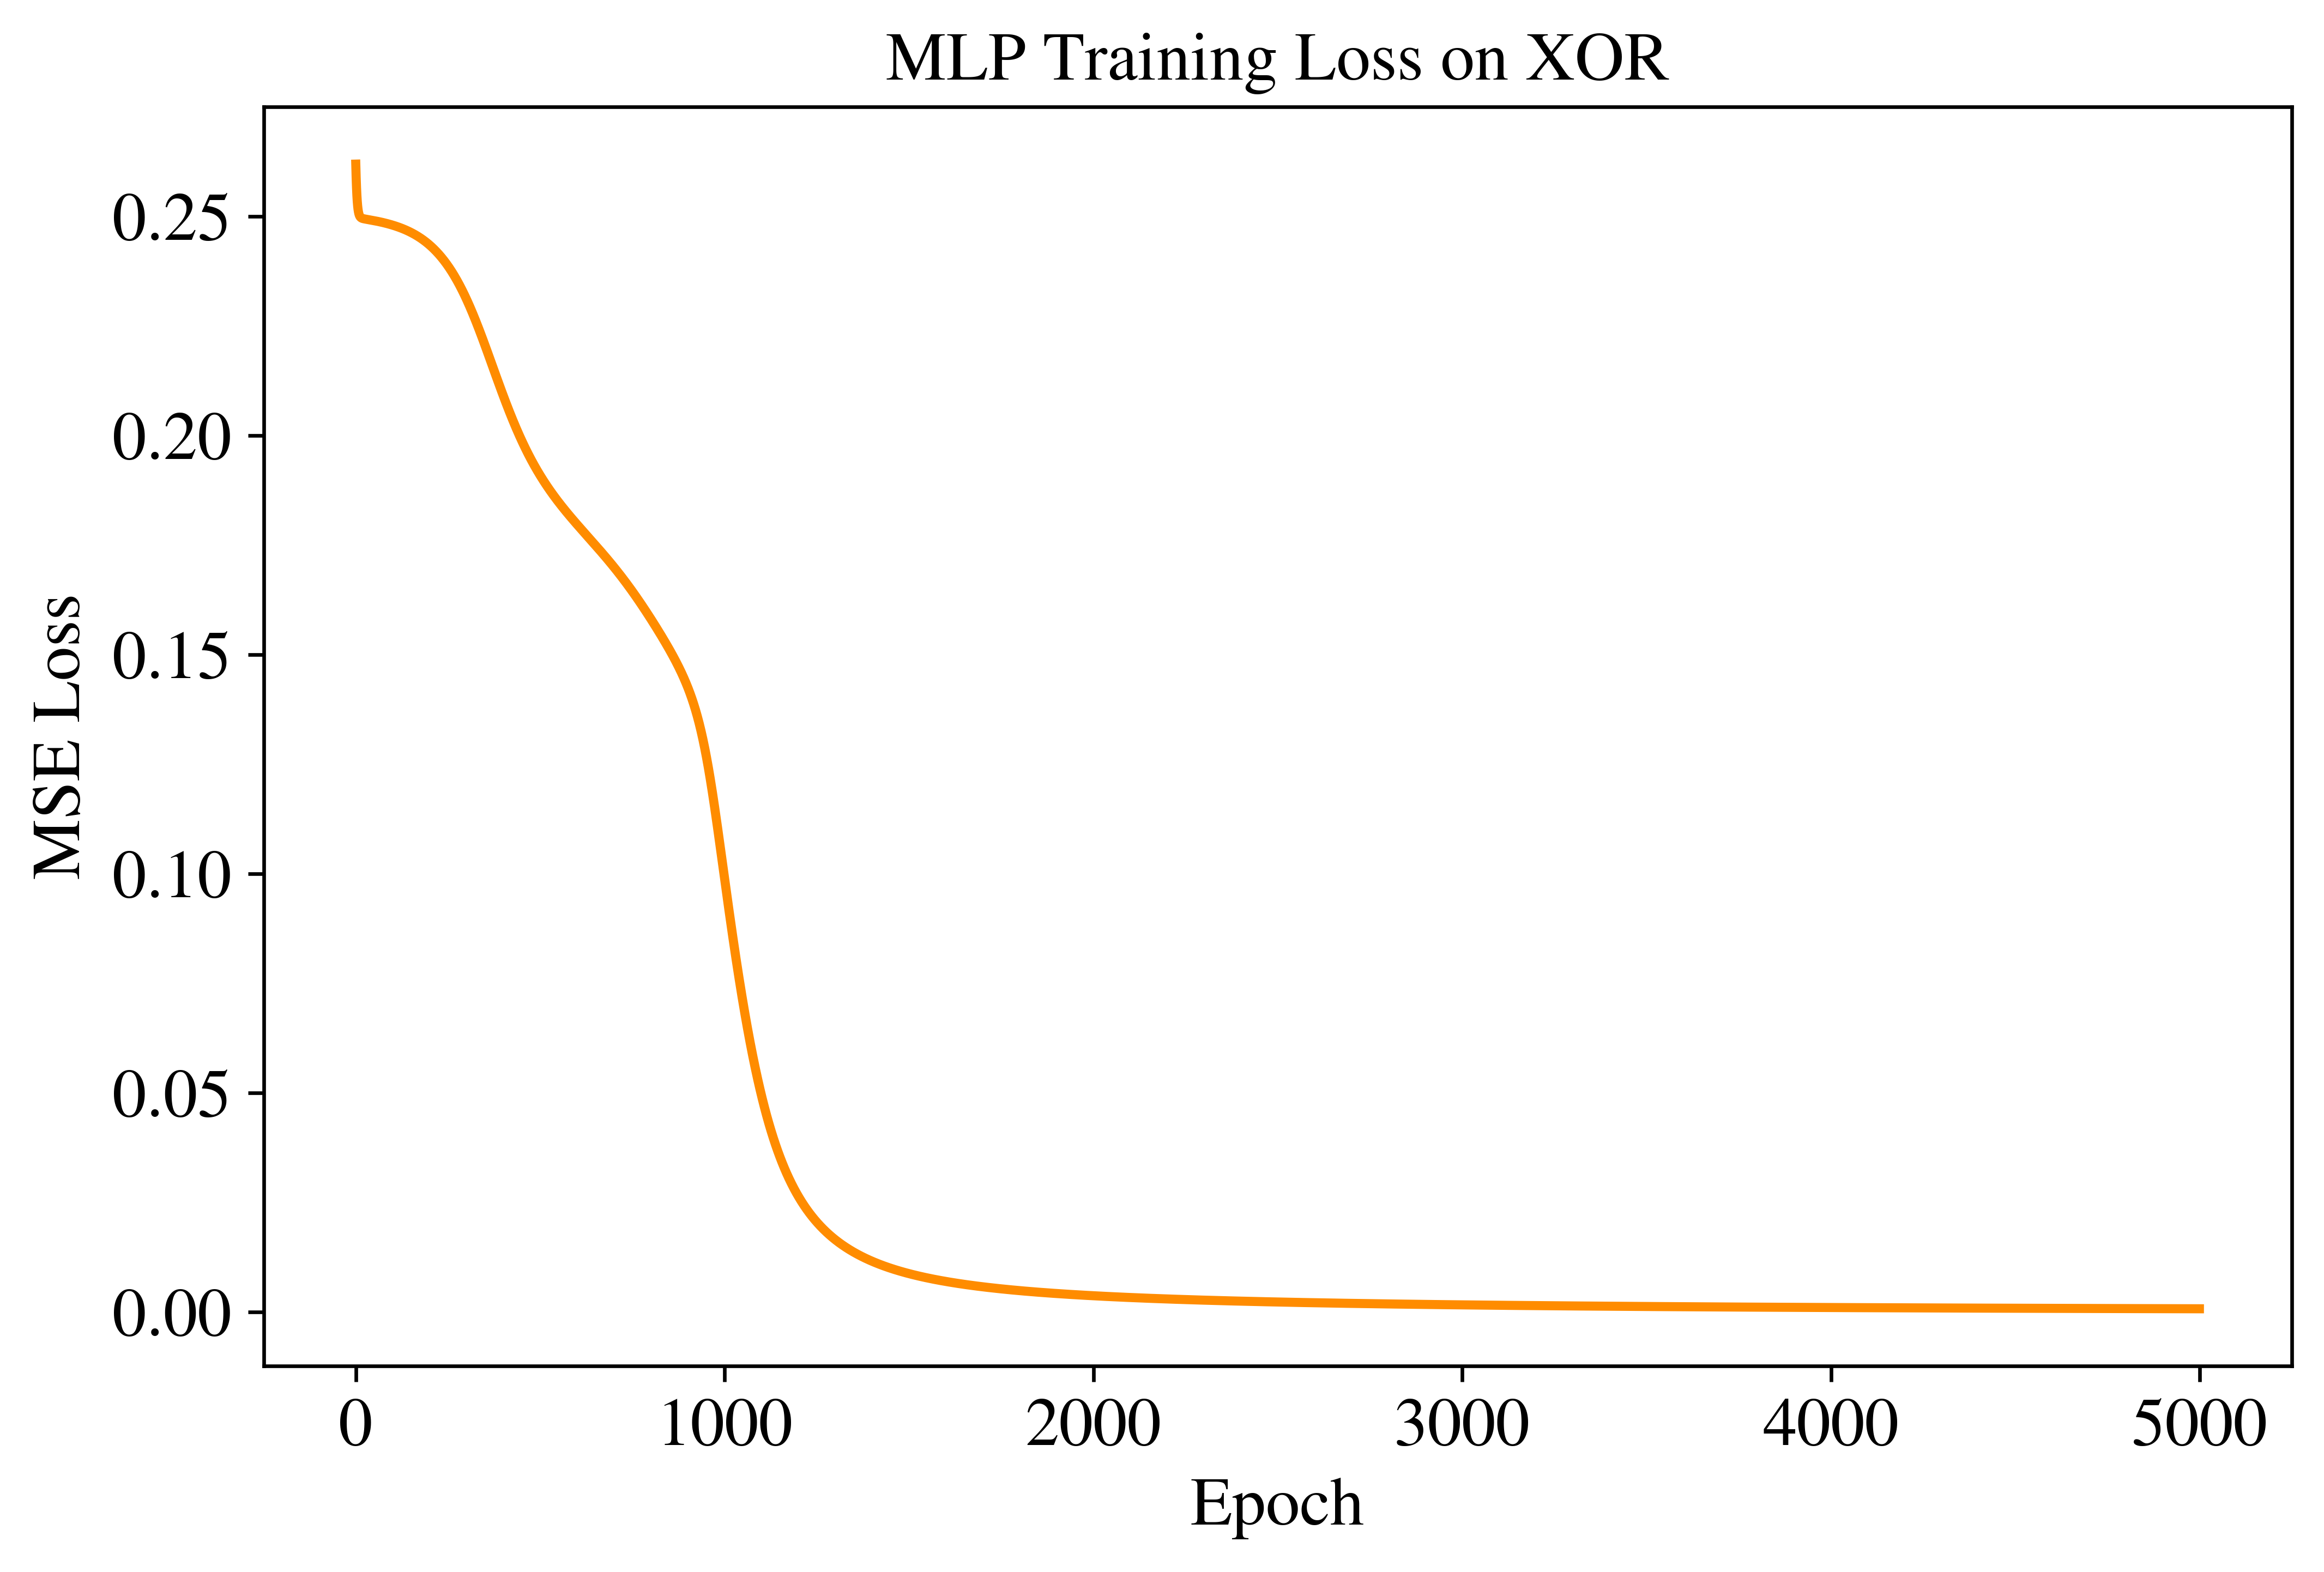

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_history, color='darkorange', linewidth=2)
ax.set_xlabel("Epoch", fontsize=15)
ax.set_ylabel("MSE Loss", fontsize=15)
ax.set_title("MLP Training Loss on XOR", fontsize=15)
save_light_eps(fig, "16_mlp_xor_loss_curve")
plt.show()


Saved /content/plots/17_mlp_xor_decision_boundary.eps  (122.8 KB)


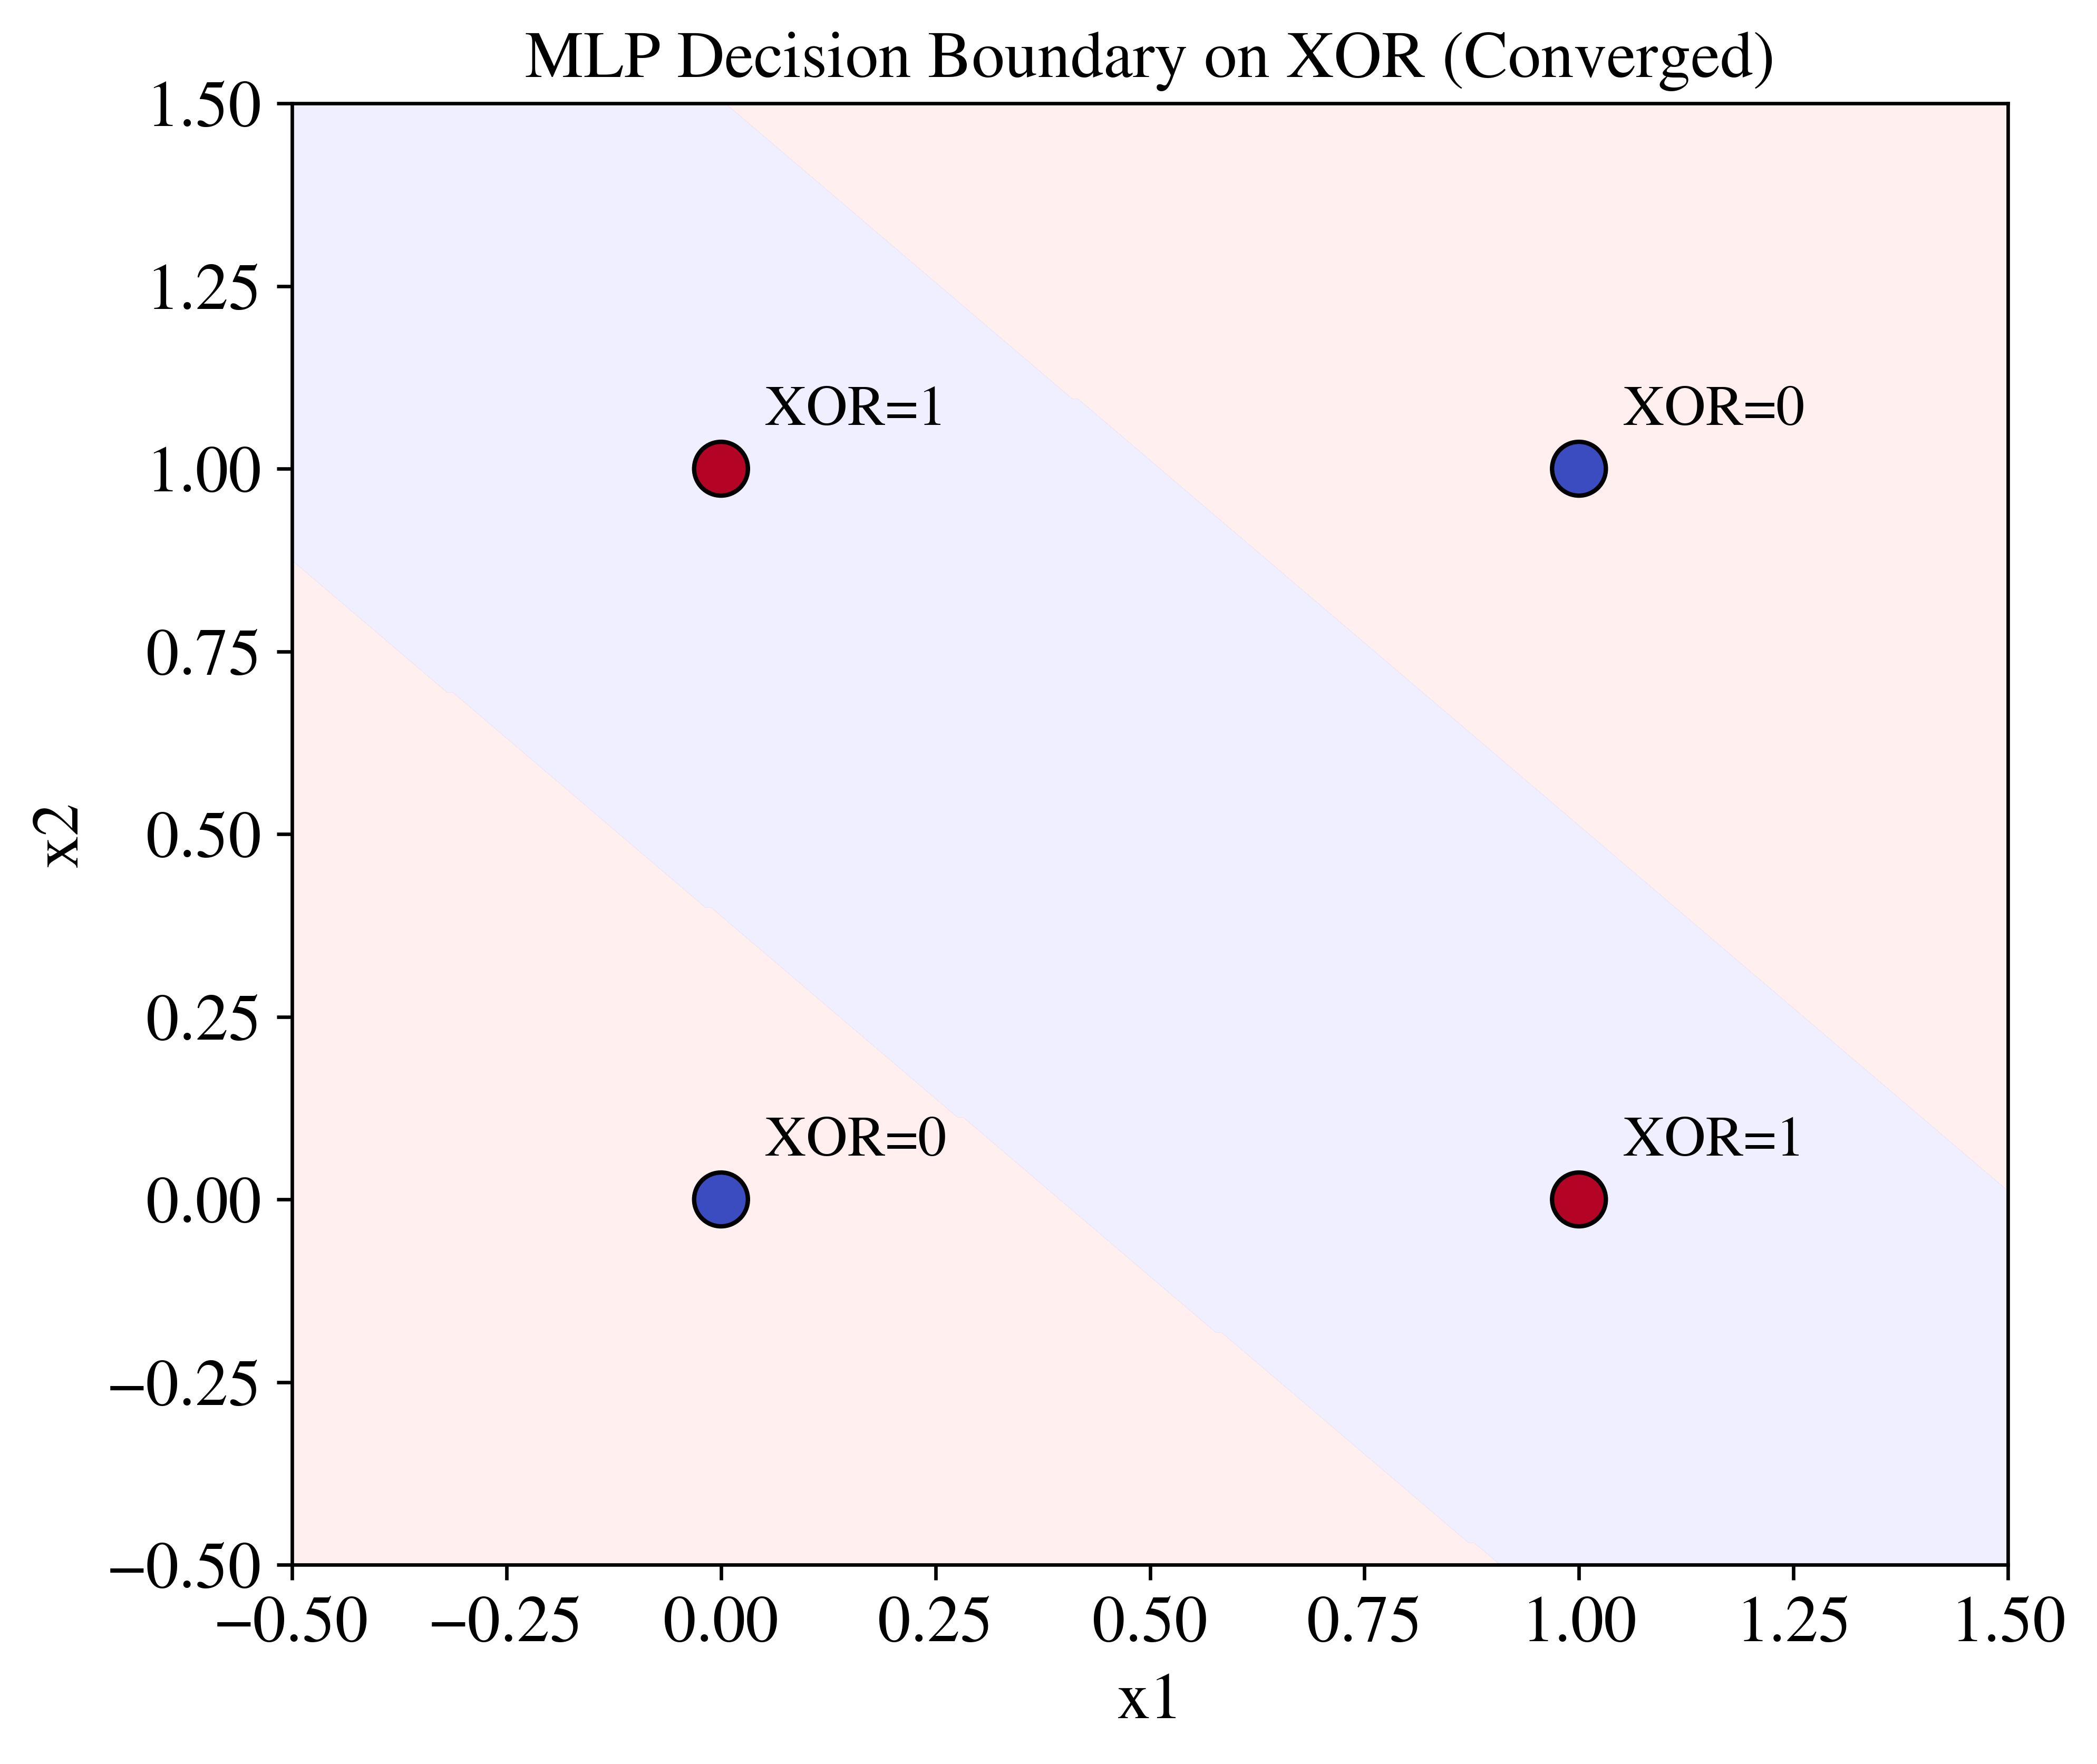

In [ ]:
def mlp_predict_grid(xx, yy):
    grid = np.c_[xx.ravel(), yy.ravel()]
    a1g = sigmoid(grid @ W1 + b1)
    a2g = sigmoid(a1g @ W2 + b2)
    return (a2g >= 0.5).astype(int).reshape(xx.shape)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
Z = mlp_predict_grid(xx, yy)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5],
            colors=['#ffcccc', '#ccccff'])
ax.scatter(X_mlp[:, 0], X_mlp[:, 1], c=y_mlp.flatten(), cmap='coolwarm',
           edgecolor='k', s=150, zorder=3)
for xi, yi in zip(X_mlp, y_mlp.flatten()):
    ax.annotate(f"XOR={int(yi)}", (xi[0], xi[1]),
                textcoords="offset points", xytext=(10, 10), fontsize=13)
ax.set_xlabel("x1", fontsize=15)
ax.set_ylabel("x2", fontsize=15)
ax.set_title("MLP Decision Boundary on XOR (Converged)", fontsize=15)
save_heavy_pdf_to_eps(fig, "17_mlp_xor_decision_boundary")
plt.show()
